In [ ]:

!pip install numpyro

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.8/394.8 kB 17.3 MB/s eta 0:00:00


In [ ]:
# check this if running on GPU
import jax

# Use 32-point precision
jax.config.update("jax_enable_x64", False)

jax.default_backend()

'gpu'

In [ ]:
jax.devices()

[CudaDevice(id=0)]

In [ ]:
# Set up file system
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [ ]:
# download the git repo
!git clone https://github.com/ConorMesser/stats_305c.git

Cloning into 'stats_305c'...
remote: Enumerating objects: 106, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 106 (delta 51), reused 61 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (106/106), 24.66 MiB | 13.09 MiB/s, done.
Resolving deltas: 100% (51/51), done.


In [ ]:
!cd stats_305c/; git pull

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 3 (delta 2), reused 3 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 282 bytes | 70.00 KiB/s, done.
From https://github.com/ConorMesser/stats_305c
   25fb726..071ff7b  main       -> origin/main
Updating 25fb726..071ff7b
Fast-forward
 pmf_model.py | 2 +-
 1 file changed, 1 insertion(+), 1 deletion(-)


In [ ]:
import stats_305c.pmf_model
import importlib

importlib.reload(stats_305c.pmf_model)

<module 'stats_305c.pmf_model' from '/content/stats_305c/pmf_model.py'>

In [ ]:
from stats_305c.pmf_model import Hybrid_PMF
from stats_305c.utils import compute_metrics, split_random_mask, split_holdout_peptides

In [ ]:

import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import os
import numpy as np
import seaborn as sns
import arviz as az
import pymc as pm
from sklearn.preprocessing import StandardScaler
import pandas as pd
import xarray as xr
import scipy.stats as stats
from scipy.stats import norm
from scipy.special import logsumexp
from pymc.sampling.jax import sample_numpyro_nuts
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import joblib


# Load and Process Data

In [ ]:
# file_path = '/content/drive/MyDrive/STATS305c/' # Lauren
file_path = '/content/drive/MyDrive/Courses/STATS305c/' # Conor

mic_file = pathlib.Path(os.path.join(file_path, 'data', 'MIC_data_cleaned.csv'))
cp_file = pathlib.Path(os.path.join(file_path, 'data', 'all_chem_phys_features.txt'))
embed_file = pathlib.Path(os.path.join(file_path, 'embeddings', 'all_embeddings.tsv'))

full_mic_data = pd.read_csv(mic_file)
all_chem_phys = pd.read_csv(cp_file, sep='\t', index_col=0)
all_chem_phys.index.name = 'Peptide ID'
all_embeddings = pd.read_csv(embed_file, sep='\t', index_col=0)
all_embeddings.index.name = 'Peptide ID'

# read in the taxonomy data
taxonomy_species = pd.read_csv(os.path.join(file_path, 'data', 'species_taxonomy.tsv'), sep='\t')
taxonomy_species['Target Species'] = taxonomy_species['strain']

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler (calculates mean and std) and transform the data
pc_features = all_chem_phys.iloc[:, 1:13]
pc_normalized_array = scaler.fit_transform(pc_features)

# It returns a numpy array, so convert it back to a DataFrame to keep your column names
pc_normalized = all_chem_phys.copy()
pc_normalized.iloc[:, 1:13] = pc_normalized_array

/tmp/ipykernel_961/1505902065.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.14303094 -2.58278073 -0.71110601 ... -0.56713103 -0.27918107
 -0.13520609]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pc_normalized.iloc[:, 1:13] = pc_normalized_array
/tmp/ipykernel_961/1505902065.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.00513085 -0.74668439 -0.02494176 ... -0.20537742  0.21563911
  0.12542129]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pc_normalized.iloc[:, 1:13] = pc_normalized_array


## Get PCs from ESM features


In [ ]:

# Assuming your esm_df has the peptide IDs as the index
# and the 1280 features as the columns.
esm_features = all_embeddings.values

# 1. Standardize the features (Crucial before PCA)
scaler = StandardScaler()
esm_scaled = scaler.fit_transform(esm_features)

# 2. Fit the full PCA to analyze the variance
pca_full = PCA()
pca_full.fit(esm_scaled)

# 3. Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# 4. Find the exact number of components for your thresholds
k_90 = np.argmax(cumulative_variance >= 0.90) + 1
k_95 = np.argmax(cumulative_variance >= 0.95) + 1
k_99 = np.argmax(cumulative_variance >= 0.99) + 1


pca_final = PCA(n_components=k_95)
esm_pca_transformed = pca_final.fit_transform(esm_scaled)

# 2. Convert back to a DataFrame to keep your peptide index intact
esm_pca_df = pd.DataFrame(
    esm_pca_transformed,
    index=all_embeddings.index,
    columns=[f"PC_{i+1}" for i in range(k_95)]
)

## Prepare data inputs
Filter species, scale by global mean, etc.

In [ ]:
# ESM and Feature inputs
phys_chem_norm = pc_normalized.iloc[:, 1:-3].astype('float32').copy()
esm_pca_input = esm_pca_df.astype('float32').copy()
esm_input = pd.DataFrame(esm_scaled, index=esm_pca_df.index).astype('float32')

# drop nas
na_peptides = phys_chem_norm[phys_chem_norm.isna().any(axis=1)].index
phys_chem_norm.drop(index=na_peptides, inplace=True)
esm_input.drop(index=na_peptides, inplace=True)

peptides_w_data = list(set(full_mic_data['Peptide ID']) & set(all_chem_phys.index))
has_data = full_mic_data[full_mic_data['Peptide ID'].isin(peptides_w_data) &
                         ~full_mic_data['Peptide ID'].isin(na_peptides)]

has_data['mic'] = np.log2(has_data['Activity_uM'].astype('float32'))

# Generate:
# - Test data (only a few species)
# - Selective species (~10) in 2 genus for testing hierarchical model
# - Abudnant species (>200 counts)
# - Most species (>10 counts)

def get_mic_df(original_df, species, name=''):
    test_mic = original_df[original_df['Target Species'].isin(species)].dropna(subset=['Peptide ID', 'Target Species', 'Activity_uM', 'Activity_low_uM'])
    mic_scaler = StandardScaler()
    test_mic['mic_transformed'] = mic_scaler.fit_transform(test_mic[['mic']].values)

    print('\nFor model:', name)
    print('Total number of observations:', test_mic.shape[0])
    print('Num peptides:', test_mic['Peptide ID'].nunique())
    print('Num strains:', test_mic['Target Species'].nunique())
    return test_mic, mic_scaler

# - Test data (only a few species)
few_species = has_data.groupby('Target Species').size().sort_values(ascending=False).iloc[:3].index
test_few_df, test_few_scaler = get_mic_df(has_data, few_species, name='test_few')

# - Selective species in 2 genus for testing hierarchical model
tmp = has_data.groupby('Target Species').size().to_frame().join(taxonomy_species.set_index('Target Species'), how='left')
tmp = tmp[tmp['genus'].isin(['Candida','Streptococcus'])]
selective_strains = tmp[(tmp[0] > 10) & (tmp[0] < 200)]['strain'].unique()
selective_df, selective_scaler = get_mic_df(has_data, selective_strains, name='test_selective')

# - Abudnant species (>200 counts)
species_counts = has_data.groupby('Target Species').size()
top_species = species_counts[species_counts > 200].index
abundant_df, abundant_scaler = get_mic_df(has_data, top_species, name='abundant')

# - Most species (>10 counts) - lower for hierarchical model
most_species = species_counts[species_counts > 10].index
most_species_df, most_species_scaler = get_mic_df(has_data, most_species, name='most_species')


/tmp/ipykernel_961/3690360576.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  has_data['mic'] = np.log2(has_data['Activity_uM'].astype('float32'))



For model: test_few
Total number of observations: 13291
Num peptides: 6128
Num strains: 3

For model: test_selective
Total number of observations: 3426
Num peptides: 2244
Num strains: 91

For model: abundant
Total number of observations: 42668
Num peptides: 10473
Num strains: 56

For model: most_species
Total number of observations: 79805
Num peptides: 12617
Num strains: 1093


In [ ]:
# train-test split not really needed given LOOCV, but we can use it for final model evaluation
train_df, hold_peptides_test = split_holdout_peptides(most_species_df, holdout_frac=0.05, random_state=42)
# train_df, random_test = split_random_mask(train_df, holdout_frac=0.10, random_state=42)

[peptide holdout]  train peptides=11987  test peptides=630  (3901 obs)


# Compare models
Moved to git already

In [ ]:
# add to git UTILS
def get_loo_comparisons(models, **kwargs):
    loo_dict = {}

    for name, model in models.items():
        if 'log_likelihood' not in model.idata.keys() or len(model.idata.log_likelihood) == 0:
            with model.model:
                pm.compute_log_likelihood(model.idata)

        loo = az.loo(model.idata, **kwargs)
        loo_dict[name] = loo

    df_comp_loo = az.compare({name: model.idata for name, model in models.items()})

    az.plot_compare(df_comp_loo)

    return loo_dict

def get_HDI_coverage(model, test_df, hdi_prob=0.95):

    # 1. Get the FULL matrix of posterior predictions
    # Shape will be (chains, draws, n_test_observations)
    posterior_preds_xr = model.predict_new_peptides(test_df, return_full_posterior=True)

    # 2. Calculate the HDI for every single test observation
    # az.hdi returns an array of shape (n_test_observations, 2) containing [lower_bound, upper_bound]
    hdi_bounds = az.hdi(posterior_preds_xr, hdi_prob=hdi_prob)["MIC_obs"].values

    # 3. Check how many true values fall inside their respective HDIs
    true_values = test_df["mic"].values
    in_interval = (true_values >= hdi_bounds[:, 0]) & (true_values <= hdi_bounds[:, 1])

    coverage_pct = in_interval.mean() * 100

    return coverage_pct

import pytensor.tensor as pt

def get_elpd_test(model, test_df, var_names=None):

    y_true = test_df["mic"].values
    posterior_preds_xr = predict_new_peptides(model, test_df, return_full_posterior=True, var_names=var_names)  # change to self call

    # # 1. Run set_data and sample_posterior_predictive as usual,
    # # but extract the underlying mu and sigma instead of the simulated MIC
    # with model.model:
    #     # (Assume set_data has already been run for the test set)
    #     ppc = pm.sample_posterior_predictive(
    #         model.idata,
    #         var_names=["mu_obs", "sigma_obs"]
    #     )

    # Extract and flatten chains/draws
    # shape: (n_samples, n_test_obs)
    ####### DEBUGGING #####
    # 1. Recreate the test-set indices (same logic from your predict_new_peptides method)
    predict_peps = test_df["Peptide ID"].unique()
    local_pep_dict = {pep: i for i, pep in enumerate(predict_peps)}

    pep_idx = test_df["Peptide ID"].map(local_pep_dict).values
    strain_idx = test_df["Target Species"].map(model.strain_dict).values

    # 2. Extract and stack the parameter samples
    # Using .transpose() to guarantee the shape is (n_samples, n_items, latent_factors)
    U_samples = posterior_preds_xr["U"].stack(sample=("chain", "draw")).transpose("sample", "peptide", "latent_factor").values
    V_samples = posterior_preds_xr["V_strains"].stack(sample=("chain", "draw")).transpose("sample", "strain", "latent_factor").values
    alpha_samples = posterior_preds_xr["alpha_peptide"].stack(sample=("chain", "draw")).transpose("sample", "peptide").values
    beta_samples = posterior_preds_xr["beta_strain"].stack(sample=("chain", "draw")).transpose("sample", "strain").values

    # 3. Broadcast the parameters to the test observations using NumPy advanced indexing
    # This pulls the specific peptide/strain parameters for every row in test_df
    U_obs = U_samples[:, pep_idx, :]       # Shape: (n_samples, n_test_obs, K)
    V_obs = V_samples[:, strain_idx, :]     # Shape: (n_samples, n_test_obs, K)
    alpha_obs = alpha_samples[:, pep_idx]   # Shape: (n_samples, n_test_obs)
    beta_obs = beta_samples[:, strain_idx]  # Shape: (n_samples, n_test_obs)

    # 4. Calculate the interaction term (Dot product along the K dimension)
    # We multiply element-wise and then sum across axis 2 (the latent factors)
    interaction = (U_obs * V_obs).sum(axis=2)

    # 5. Build the final mu_samples matrix
    # Shape will be (n_samples, n_test_obs)
    mu_test_samples = alpha_obs + beta_obs + interaction

    ####################
    # mu_test_samples = posterior_preds_xr["mu_obs"].stack(sample=("chain", "draw")).values.T
    sigma_samples = posterior_preds_xr["sigma_obs"].stack(sample=("chain", "draw")).values

    # 2. Calculate log likelihood of the true test data for every posterior sample
    # shape: (n_samples, n_test_obs)
    log_lik_matrix = norm.logpdf(y_true, loc=mu_test_samples, scale=sigma_samples[:, None])

    # 3. Average the probabilities (in log space) across all posterior samples for each test point
    n_samples = log_lik_matrix.shape[0]
    test_point_elpd = logsumexp(log_lik_matrix, axis=0) - np.log(n_samples)

    # 4. Sum to get the total Test ELPD (Higher/less negative is better)
    total_test_elpd = test_point_elpd.sum()
    return total_test_elpd, test_point_elpd


def predict_new_peptides(model, new_long_df, return_full_posterior=False, var_names=None):
    # 1. Identify the unique peptides in this specific prediction batch
    predict_peps = new_long_df["Peptide ID"].unique()

    # 2. Extract their features from your master dataframes
    # Assumes original_idx is a column containing the Peptide IDs
    pc_df_predict = model.pc_df[model.pc_df['original_idx'].isin(predict_peps)]
    esm_df_predict = model.esm_df[model.esm_df['original_idx'].isin(predict_peps)]

    # 3. Create a LOCAL dictionary mapping to 0, 1, 2... N
    # This prevents the PyMC IndexError trap
    local_pep_dict = {pep: i for i, pep in enumerate(predict_peps)}

    # 4. Map the observation dataframe to these local indices
    obs_peptide_idx = new_long_df["Peptide ID"].map(local_pep_dict).values

    # 5. Extract feature matrices in the exact order of the local dictionary
    # Make sure to set the index to Peptide ID temporarily so .loc alignment works perfectly
    pc_input = pc_df_predict.set_index('original_idx').loc[predict_peps]
    esm_input = esm_df_predict.set_index('original_idx').loc[predict_peps]

    # Ensure all target species exist in the training dictionary
    assert len(set(new_long_df["Target Species"]) - set(model.strain_dict.keys())) == 0, \
        "Cannot predict for a species not in the training set!"

    obs_strain_idx = new_long_df["Target Species"].map(model.strain_dict).values

    with model.model:
        pm.set_data(
            {
                "pep_idx": obs_peptide_idx,
                "strain_idx": obs_strain_idx,
                "mic": np.ones(len(new_long_df)),  # Dummy values for shape
                "X_pc": pc_input.values,
                "X_esm": esm_input.values,
            },
            coords={
                "obs_id": range(len(new_long_df)),
                "peptide": range(len(predict_peps)),
            },
        )

        idata = model.idata if hasattr(model, 'idata') and model.idata else model.idata_vi
        ppc = pm.sample_posterior_predictive(idata, extend_inferencedata=False, var_names=var_names)
    var_names = ["MIC_obs"] if var_names is None else var_names
    raw = ppc.posterior_predictive[var_names]
    return raw if return_full_posterior else raw.mean(("chain", "draw")).values

### Test functions

In [ ]:
idata = az.from_netcdf(os.path.join(file_path, "saved_models", "hpmf_model_ESMPC_noHie2.5_16.selective.nc"))
hpmf_model_ESMPC_noHie = Hybrid_PMF(selective_df.copy(), phys_chem_norm.copy(), esm_pca_input.copy(),
                                 taxonomy_species, dim=5,
                                 include_esm=True, horseshoe=False, hierarchical=False, anchor_pc=False)
hpmf_model_ESMPC_noHie.idata = idata

/usr/local/lib/python3.12/dist-packages/pytensor/tensor/blas.py:1727: FutureWarning: batched_dot is deprecated. Use `dot` in conjunction with `tensor.vectorize` or `graph.replace.vectorize_graph`
  warnings.warn(


In [ ]:
tmp_test_set = hold_peptides_test[hold_peptides_test['Target Species'].isin(selective_df['Target Species'].unique())]
tmp_test_set = train_df[train_df['Target Species'].isin(selective_df['Target Species'].unique())]

get_HDI_coverage(hpmf_model_ESMPC_noHie, tmp_test_set, hdi_prob=0.5)


Output()

np.float64(69.6248856358646)

In [ ]:

total_test_elpd, test_point_elpd = get_elpd_test(hpmf_model_ESMPC_noHie, tmp_test_set, var_names=["MIC_obs", "sigma_obs", "V_strains", "U", "alpha_peptide", "beta_strain"])

Output()

In [ ]:

np.exp(test_point_elpd.mean())

np.float64(0.017635321348186527)

# Compare no hierarchical to hierarchical
Try on selective_df to start, with PCA ESM features, no horseshoe

## Selective to start (not as useful)

In [ ]:

hpmf_model_ESMPC_noHie = Hybrid_PMF(selective_df.copy(), phys_chem_norm.copy(), esm_pca_input.copy(),
                                 taxonomy_species, dim=5,
                                 include_esm=True, horseshoe=False, hierarchical=False, anchor_pc=False)

hpmf_model_ESMPC_noHie.draw_samples(draws=1000, tune=1000, nuts_sampler="numpyro", init="jitter+adapt_diag", n_init=50000, chains=1)  # init="jitter+adapt_diag", n_init=50000,


/usr/local/lib/python3.12/dist-packages/pytensor/tensor/blas.py:1727: FutureWarning: batched_dot is deprecated. Use `dot` in conjunction with `tensor.vectorize` or `graph.replace.vectorize_graph`
  warnings.warn(
sample: 100%|██████████| 2000/2000 [17:58<00:00,  1.85it/s, 511 steps of size 7.24e-03. acc. prob=0.88]
/usr/local/lib/python3.12/dist-packages/jax/_src/interpreters/mlir.py:1334: UserWarning: Some donated buffers were not usable: float64[1,1000,90].
See an explanation at https://docs.jax.dev/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

In [ ]:

hpmf_model_ESMPC_Hie = Hybrid_PMF(selective_df.copy(), phys_chem_norm.copy(), esm_pca_input.copy(),
                                 taxonomy_species, dim=5,
                                 include_esm=True, horseshoe=False, hierarchical=True, anchor_pc=False)

hpmf_model_ESMPC_Hie.draw_samples(draws=1000, tune=1000, nuts_sampler="numpyro", init="jitter+adapt_diag", n_init=50000, chains=1)  # init="jitter+adapt_diag", n_init=50000,


/usr/local/lib/python3.12/dist-packages/pytensor/tensor/blas.py:1727: FutureWarning: batched_dot is deprecated. Use `dot` in conjunction with `tensor.vectorize` or `graph.replace.vectorize_graph`
  warnings.warn(
sample: 100%|██████████| 2000/2000 [18:27<00:00,  1.81it/s, 511 steps of size 1.11e-02. acc. prob=0.89]
/usr/local/lib/python3.12/dist-packages/jax/_src/interpreters/mlir.py:1334: UserWarning: Some donated buffers were not usable: float64[1,1000,349].
See an explanation at https://docs.jax.dev/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

In [ ]:
hpmf_model_ESMPC_noHie.idata.to_netcdf(os.path.join(file_path, "saved_models", "hpmf_model_ESMPC_noHie2.5_16.selective.nc"))
hpmf_model_ESMPC_Hie.idata.to_netcdf(os.path.join(file_path, "saved_models", "hpmf_model_ESMPC_Hie2.5_16.selective.nc"))

'/content/drive/MyDrive/Courses/STATS305c/saved_models/hpmf_model_ESMPC_Hie2.5_16.selective.nc'

In [ ]:
idata = az.from_netcdf(os.path.join(file_path, "saved_models", "hpmf_model_ESMPC_noHie2.5_16.selective.nc"))
hpmf_model_ESMPC_noHie = Hybrid_PMF(selective_df.copy(), phys_chem_norm.copy(), esm_pca_input.copy(),
                                 taxonomy_species, dim=5,
                                 include_esm=True, horseshoe=False, hierarchical=False, anchor_pc=False)
hpmf_model_ESMPC_noHie.idata = idata

idata = az.from_netcdf(os.path.join(file_path, "saved_models", "hpmf_model_ESMPC_Hie2.5_16.selective.nc"))
hpmf_model_ESMPC_Hie = Hybrid_PMF(selective_df.copy(), phys_chem_norm.copy(), esm_pca_input.copy(),
                                 taxonomy_species, dim=5,
                                 include_esm=True, horseshoe=False, hierarchical=True, anchor_pc=False)
hpmf_model_ESMPC_Hie.idata = idata


/usr/local/lib/python3.12/dist-packages/pytensor/tensor/blas.py:1727: FutureWarning: batched_dot is deprecated. Use `dot` in conjunction with `tensor.vectorize` or `graph.replace.vectorize_graph`
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pytensor/tensor/blas.py:1727: FutureWarning: batched_dot is deprecated. Use `dot` in conjunction with `tensor.vectorize` or `graph.replace.vectorize_graph`
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.67 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.67 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimat

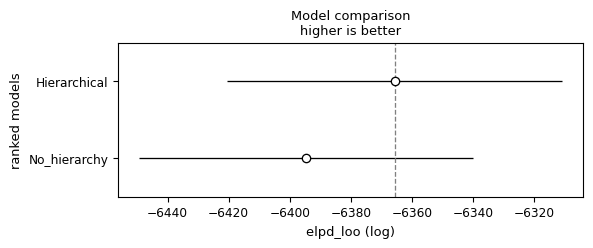

In [ ]:
hierarchical_loos = get_loo_comparisons({'No_hierarchy': hpmf_model_ESMPC_noHie,
                                     'Hierarchical': hpmf_model_ESMPC_Hie}, pointwise=True)

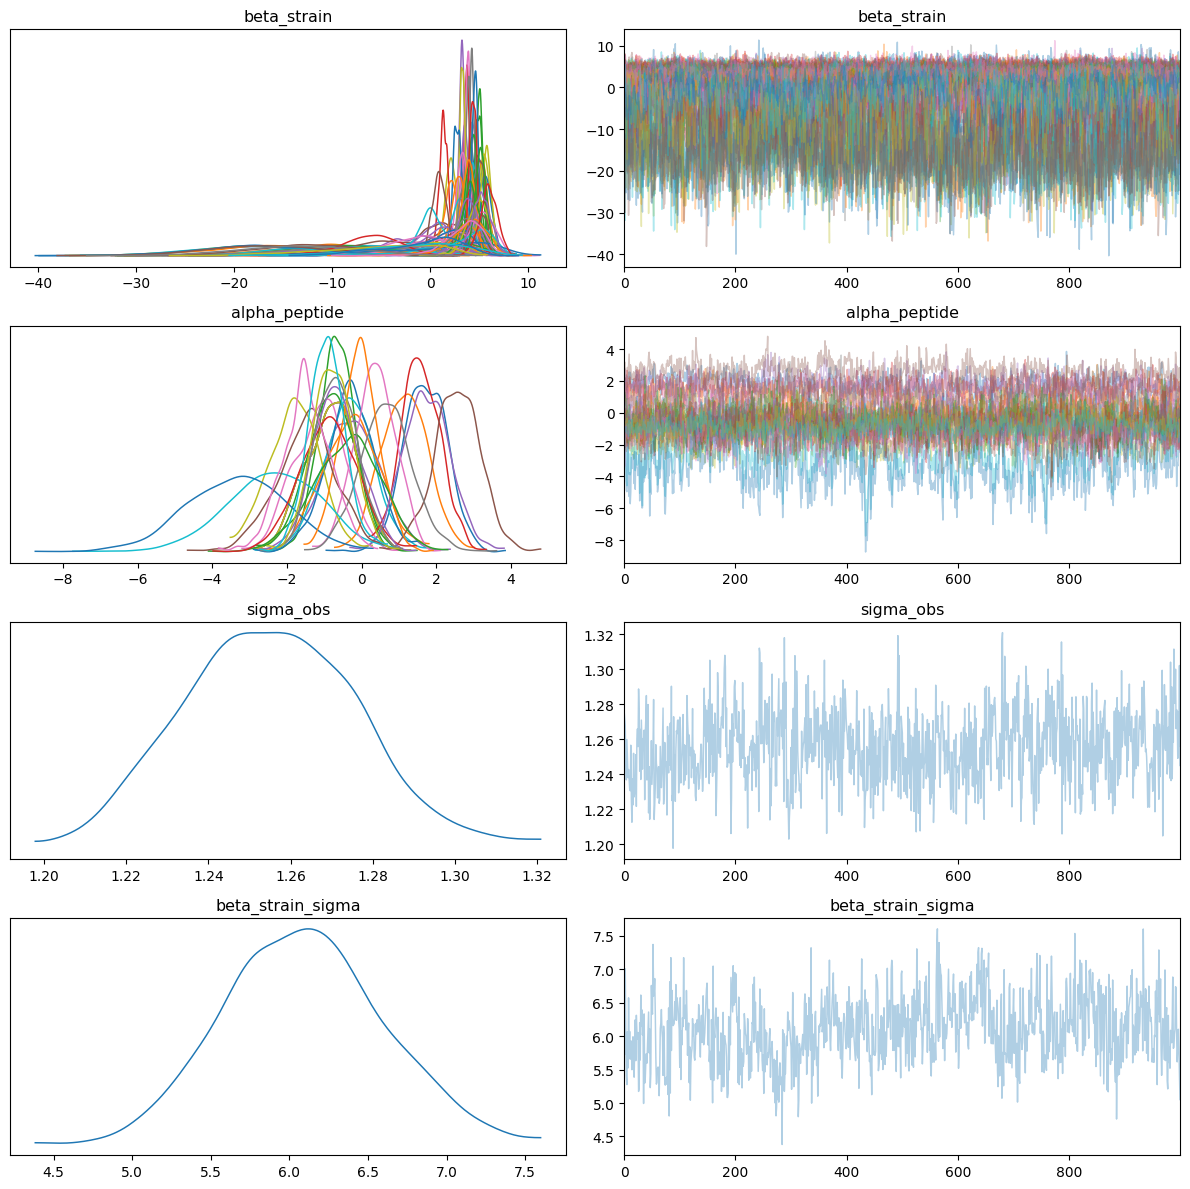

In [ ]:
hpmf_model_ESMPC_noHie.plot_intercept_traces(#hpmf_model_ESMPC_noHie,
    species_list=selective_df['Target Species'].unique(),
    peptide_list=selective_df['Peptide ID'].unique()[:30]
)

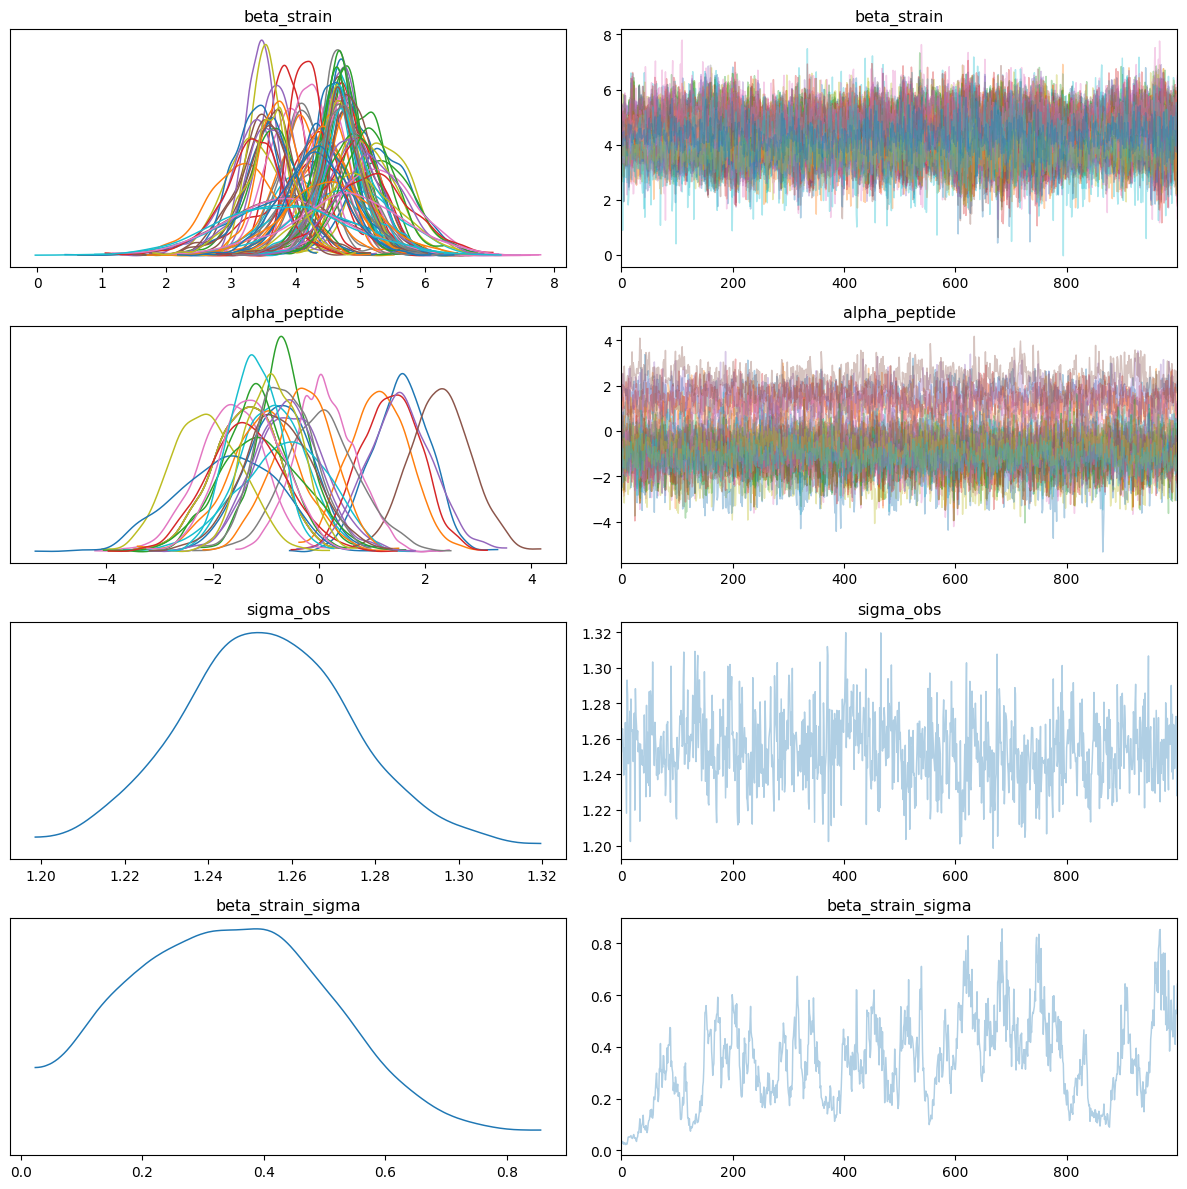

In [ ]:
hpmf_model_ESMPC_Hie.plot_intercept_traces(
    species_list=selective_df['Target Species'].unique(),
    peptide_list=selective_df['Peptide ID'].unique()[:30]
)

In [ ]:
selective_df[selective_df['Target Species'].isin(selective_df['Target Species'].unique()[18:20])]['mic_transformed'].describe()

,mic_transformed
count,77.000000
mean,0.089969
std,1.385495
min,-2.250296
25%,-1.106497
50%,-0.212028
75%,2.098303
max,2.098303


Plot LOO values for each observation

<Axes: xlabel='loo_i_H', ylabel='loo_i_NonH'>

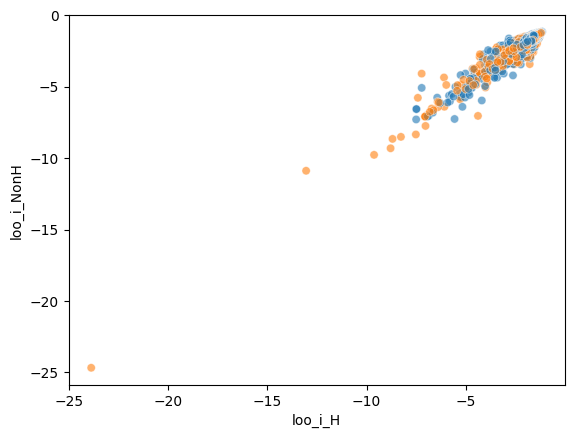

In [ ]:
tmp_df = selective_df.merge(taxonomy_species.drop_duplicates(subset='Target Species'), on='Target Species', how='left')
tmp_df['loo_i_NonH'] = hierarchical_loos['No_hierarchy']['loo_i'].values
tmp_df['loo_i_H'] = hierarchical_loos['Hierarchical']['loo_i'].values

sns.scatterplot(tmp_df, x='loo_i_H', y='loo_i_NonH', hue='genus',legend=False, alpha=0.6)

Plot mean posterior value for each strain against number of obs for the strain; color by species, then by genus

In [ ]:
strains = list(hpmf_model_ESMPC_Hie.strain_dict.keys())
tmp_df = taxonomy_species.drop_duplicates().set_index('Target Species').loc[strains]
beta_strain_H = hpmf_model_ESMPC_Hie.idata.posterior["beta_strain"].mean(dim=("chain","draw")).values
beta_strain_NoH = hpmf_model_ESMPC_noHie.idata.posterior["beta_strain"].mean(dim=("chain","draw")).values

counts = selective_df['Target Species'].value_counts()
tmp_df['beta_strain_H'] = beta_strain_H
tmp_df['beta_strain_NoH'] = beta_strain_NoH
tmp_df['obs_counts'] = counts.loc[strains]

stacked_df = tmp_df.melt(
    id_vars=['obs_counts', 'genus'],
    value_vars=['beta_strain_H', 'beta_strain_NoH'],
    var_name='model',
    value_name='beta_strain_means'
)
sns.scatterplot(stacked_df, x='obs_counts', y='beta_strain_means', hue='model')

NameError: name 'hpmf_model_ESMPC_Hie' is not defined

In [ ]:
stacked_df = tmp_df.melt(
    id_vars=['obs_counts', 'genus'],
    value_vars=['beta_strain_H', 'beta_strain_NoH'],
    var_name='model',
    value_name='beta_strain_means'
)

<Axes: xlabel='obs_counts', ylabel='beta_strain_means'>

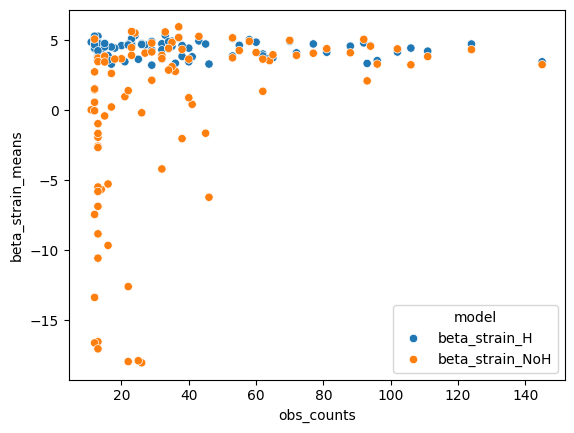

In [ ]:
sns.scatterplot(stacked_df, x='obs_counts', y='beta_strain_means', hue='model')

Plot mean posterior value for each peptide against number of obs for the peptide; color by different features?

In [ ]:
peptides = list(hpmf_model_ESMPC_Hie.peptide_dict.keys())
# tmp_df = taxonomy_species.drop_duplicates().set_index('Target Species').loc[strains]
alpha_peptide_H = hpmf_model_ESMPC_Hie.idata.posterior["alpha_peptide"].mean(dim=("chain","draw")).values
alpha_peptide_NoH = hpmf_model_ESMPC_noHie.idata.posterior["alpha_peptide"].mean(dim=("chain","draw")).values

counts = selective_df['Peptide ID'].value_counts().to_frame()
counts['alpha_peptide_H'] = alpha_peptide_H
counts['alpha_peptide_NoH'] = alpha_peptide_NoH
# counts['obs_counts'] = counts.loc[peptides]

<Axes: xlabel='count', ylabel='alpha_peptide_means'>

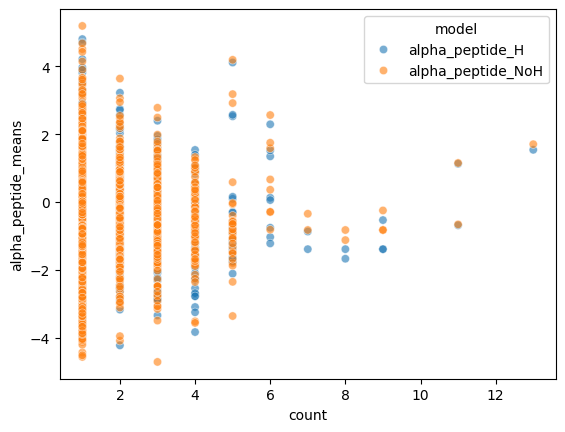

In [ ]:
stacked_df = counts.melt(
    id_vars=['count'],
    value_vars=['alpha_peptide_H', 'alpha_peptide_NoH'],
    var_name='model',
    value_name='alpha_peptide_means'
)
sns.scatterplot(stacked_df, x='count', y='alpha_peptide_means', hue='model',alpha=0.6)

## Official models (full dataset)

In [ ]:

idata = az.from_netcdf(os.path.join(file_path, "saved_models", "hpmf_model_wESM.5_16.gt_10_species.nc"))
hpmf_model_wESM = Hybrid_PMF(most_species_df.copy(), phys_chem_norm.copy(), esm_input.copy(),
                                     taxonomy_species, dim=5, include_esm=True, horseshoe=False, linreg=False,
                                     sigma_obs_sigma=1, b_pc_sigma=1, b_esm_sigma=1, beta_strains_sigma=1,)
hpmf_model_wESM.idata = idata

idata = az.from_netcdf(os.path.join(file_path, "saved_models", "hpmf_model_wESM_Hie.5_16.gt_10_species.nc"))
hpmf_model_wESM_Hie = Hybrid_PMF(most_species_df.copy(), phys_chem_norm.copy(), esm_input.copy(),  # re-run to ensure both are on esm (not ESM pca)? Or find one I already ran??
                                 taxonomy_species, dim=5,
                                 include_esm=True, horseshoe=False, hierarchical=True, anchor_pc=False,
                                        sigma_obs_sigma=1, b_pc_sigma=1, b_esm_sigma=1, beta_strains_sigma=1)
hpmf_model_wESM_Hie.idata = idata

/usr/local/lib/python3.12/dist-packages/pytensor/tensor/blas.py:1727: FutureWarning: batched_dot is deprecated. Use `dot` in conjunction with `tensor.vectorize` or `graph.replace.vectorize_graph`
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pytensor/tensor/blas.py:1727: FutureWarning: batched_dot is deprecated. Use `dot` in conjunction with `tensor.vectorize` or `graph.replace.vectorize_graph`
  warnings.warn(


<Axes: xlabel='obs_counts', ylabel='beta_strain_means'>

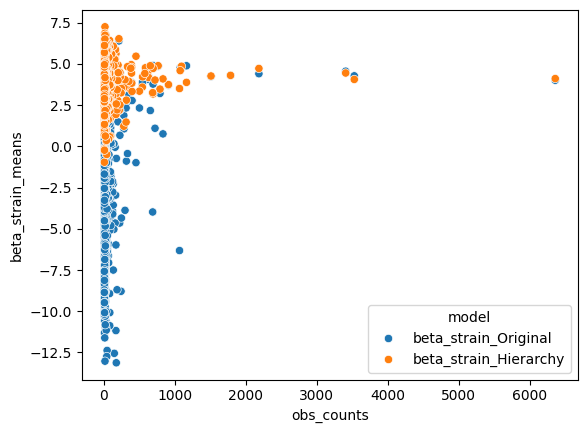

In [ ]:
strains = list(hpmf_model_wESM_Hie.strain_dict.keys())
tmp_df = taxonomy_species.drop_duplicates().set_index('Target Species').loc[strains]

beta_strain_H = hpmf_model_wESM_Hie.idata.posterior["beta_strain"].mean(dim=("chain","draw")).values
beta_strain_NoH = hpmf_model_wESM.idata.posterior["beta_strain"].mean(dim=("chain","draw")).values

counts = most_species_df['Target Species'].value_counts()
tmp_df['beta_strain_Hierarchy'] = beta_strain_H
tmp_df['beta_strain_Original'] = beta_strain_NoH
tmp_df['obs_counts'] = counts.loc[strains]

species_sums = tmp_df.groupby('species')['obs_counts'].sum()
species_sums.name = 'species_counts'
tmp_df = tmp_df.merge(species_sums, right_index=True, left_on='species')
genus_sums = tmp_df.groupby('genus')['obs_counts'].sum()
genus_sums.name = 'genus_counts'
tmp_df = tmp_df.merge(genus_sums, right_index=True, left_on='genus')

stacked_df = tmp_df.melt(
    id_vars=['obs_counts', 'genus'],
    value_vars=['beta_strain_Original', 'beta_strain_Hierarchy'],
    var_name='model',
    value_name='beta_strain_means'
)
sns.scatterplot(stacked_df, x='obs_counts', y='beta_strain_means', hue='model')

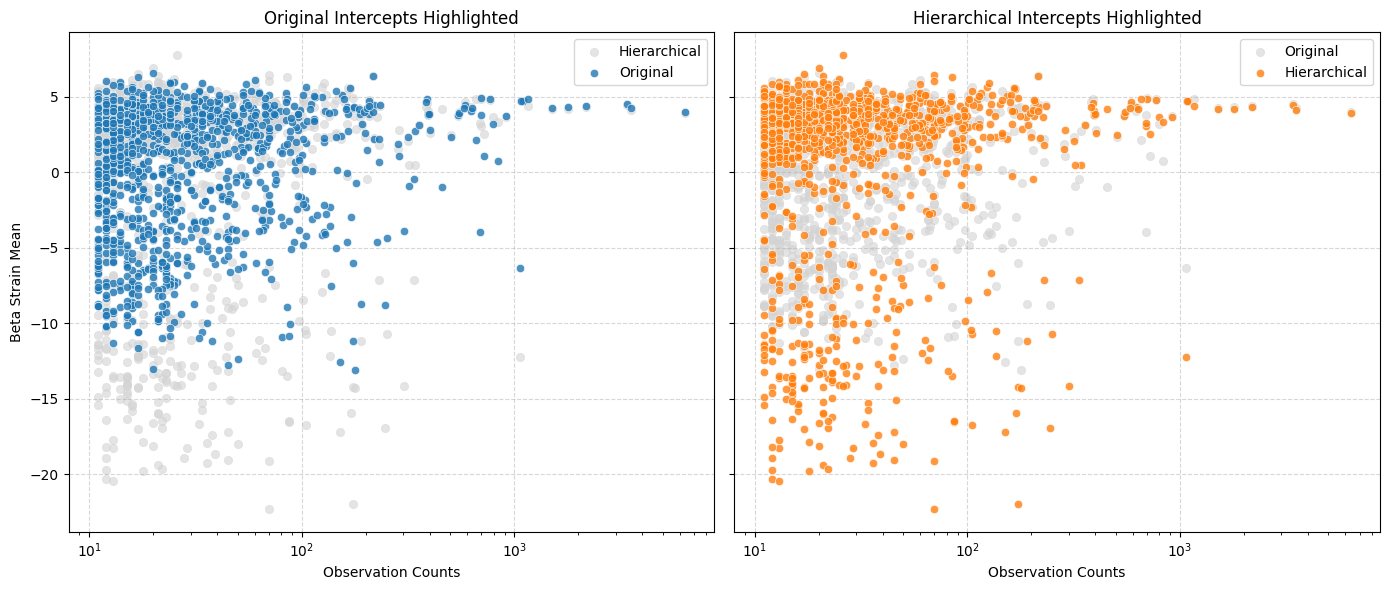

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------------------------------------------------
# Subplot 1: Hierarchy (Gray/Bg) vs Original (Colored/Fg)
# ---------------------------------------------------------
# 1. Background layer (zorder=1)
sns.scatterplot(
    data=tmp_df, x='obs_counts', y='beta_strain_Hierarchy',
    color='lightgray', alpha=0.6, edgecolor=None,
    ax=axes[0], zorder=1, label='Hierarchical'
)
# 2. Foreground layer (zorder=2)
sns.scatterplot(
    data=tmp_df, x='obs_counts', y='beta_strain_Original',
    color='tab:blue', alpha=0.8, edgecolor='w', linewidth=0.5,
    ax=axes[0], zorder=2, label='Original'
)
axes[0].set_title("Original Intercepts Highlighted")
axes[0].set_ylabel("Beta Strain Mean")
axes[0].set_xlabel("Observation Counts")

# ---------------------------------------------------------
# Subplot 2: Original (Gray/Bg) vs Hierarchy (Colored/Fg)
# ---------------------------------------------------------
# 1. Background layer (zorder=1)
sns.scatterplot(
    data=tmp_df, x='obs_counts', y='beta_strain_Original',
    color='lightgray', alpha=0.6, edgecolor=None,
    ax=axes[1], zorder=1, label='Original'
)
# 2. Foreground layer (zorder=2)
sns.scatterplot(
    data=tmp_df, x='obs_counts', y='beta_strain_Hierarchy',
    color='tab:orange', alpha=0.8, edgecolor='w', linewidth=0.5,
    ax=axes[1], zorder=2, label='Hierarchical'
)
axes[1].set_title("Hierarchical Intercepts Highlighted")
axes[1].set_xlabel("Observation Counts")

# --- Formatting ---
for ax in axes:
    # Highly recommend log scale for count data so the
    # low-count strains (where shrinkage is strongest) aren't crushed
    ax.set_xscale('log')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()

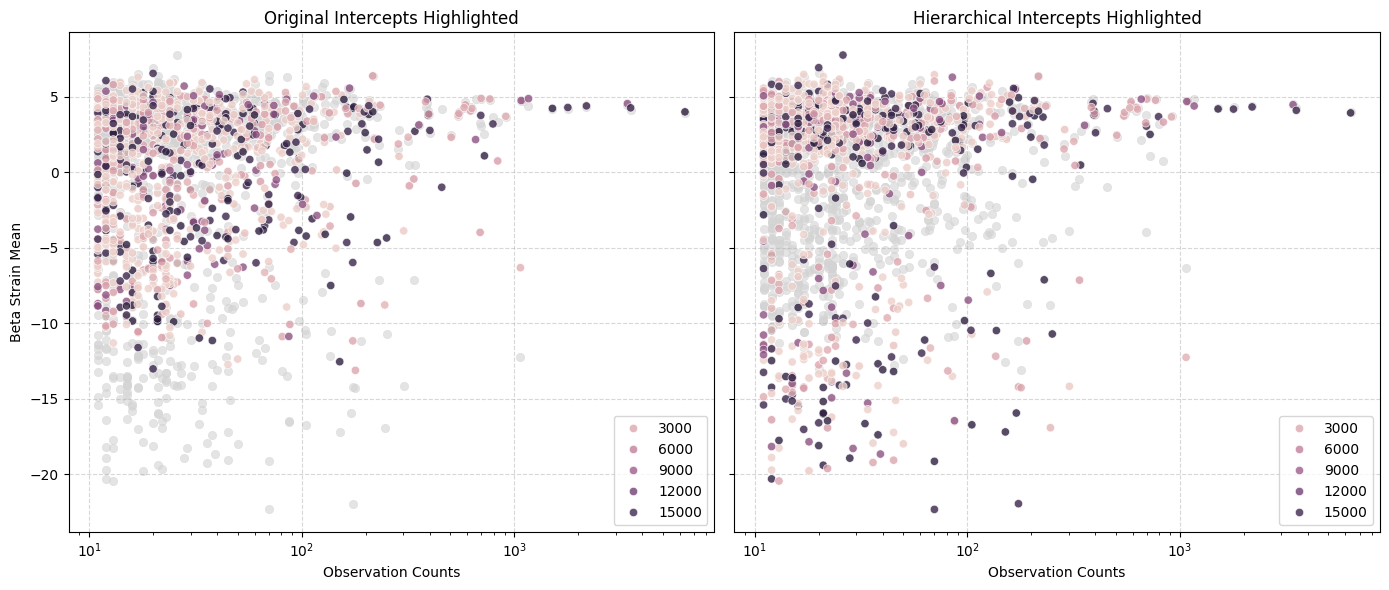

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------------------------------------------------
# Subplot 1: Hierarchy (Gray/Bg) vs Original (Colored/Fg)
# ---------------------------------------------------------
# 1. Background layer (zorder=1)
sns.scatterplot(
    data=tmp_df, x='obs_counts', y='beta_strain_Hierarchy',
    color='lightgray', alpha=0.6, edgecolor=None,
    ax=axes[0], zorder=1#, label='Hierarchical'
)
# 2. Foreground layer (zorder=2)
sns.scatterplot(
    data=tmp_df, x='obs_counts', y='beta_strain_Original',
    hue='species_counts', alpha=0.8, edgecolor='w', linewidth=0.5,
    ax=axes[0], zorder=2#, label='Original'
)
axes[0].set_title("Original Intercepts Highlighted")
axes[0].set_ylabel("Beta Strain Mean")
axes[0].set_xlabel("Observation Counts")

# ---------------------------------------------------------
# Subplot 2: Original (Gray/Bg) vs Hierarchy (Colored/Fg)
# ---------------------------------------------------------
# 1. Background layer (zorder=1)
sns.scatterplot(
    data=tmp_df, x='obs_counts', y='beta_strain_Original',
    color='lightgray', alpha=0.6, edgecolor=None,
    ax=axes[1], zorder=1#, label='Original'
)
# 2. Foreground layer (zorder=2)
sns.scatterplot(
    data=tmp_df, x='obs_counts', y='beta_strain_Hierarchy',
    hue='species_counts', alpha=0.8, edgecolor='w', linewidth=0.5,
    ax=axes[1], zorder=2#, label='Hierarchical'
)
axes[1].set_title("Hierarchical Intercepts Highlighted")
axes[1].set_xlabel("Observation Counts")

# --- Formatting ---
for ax in axes:
    # Highly recommend log scale for count data so the
    # low-count strains (where shrinkage is strongest) aren't crushed
    ax.set_xscale('log')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()

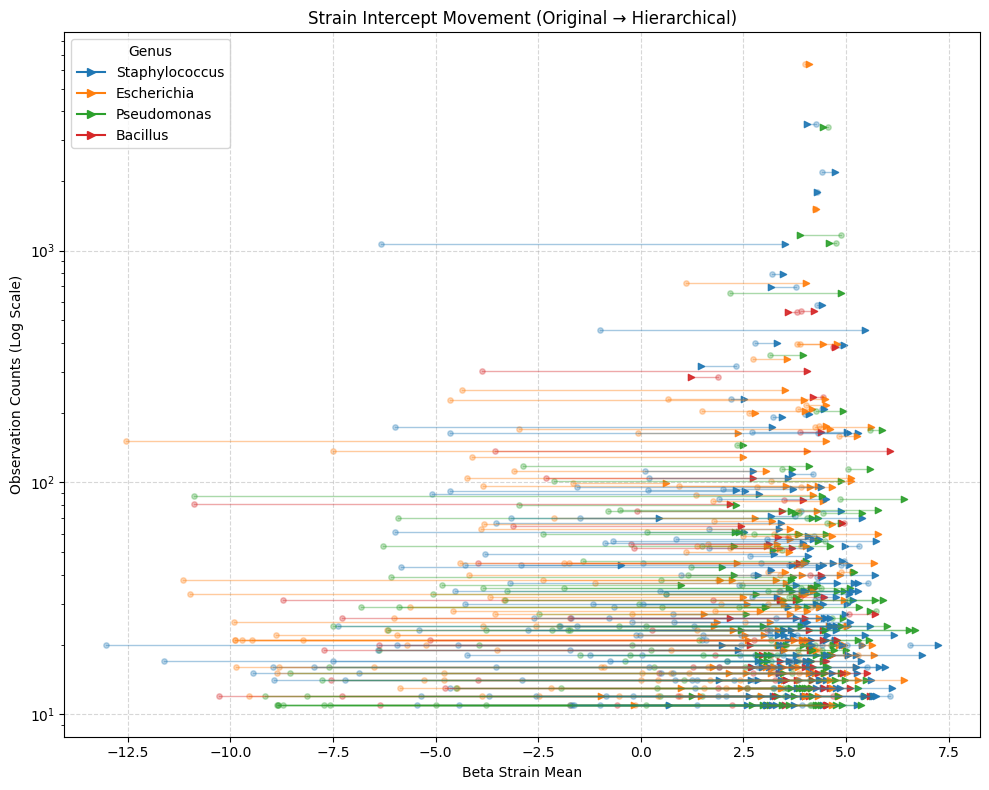

In [ ]:
# 1. Identify the top 4 most abundant genera to keep the plot legible
top_genera = tmp_df['genus'].value_counts().nlargest(4).index
subset_df = tmp_df[tmp_df['genus'].isin(top_genera)]

plt.figure(figsize=(10, 8))
colors = sns.color_palette("tab10", n_colors=len(top_genera))
genus_color_map = dict(zip(top_genera, colors))

for _, row in subset_df.iterrows():
    color = genus_color_map[row['genus']]
    x_start = row['beta_strain_Original']
    x_end = row['beta_strain_Hierarchy']

    # Draw the line connecting Original to Hierarchy
    plt.plot([x_start, x_end], [row['obs_counts'], row['obs_counts']],
             color=color, alpha=0.4, linewidth=1)

    # Plot the endpoints
    plt.scatter(x_start, row['obs_counts'], color=color, alpha=0.3, s=15, marker='o') # Original
    plt.scatter(x_end, row['obs_counts'], color=color, alpha=0.9, s=20, marker='>')   # Hierarchy

plt.yscale('log')
plt.title("Strain Intercept Movement (Original → Hierarchical)")
plt.xlabel("Beta Strain Mean")
plt.ylabel("Observation Counts (Log Scale)")

# Custom legend
handles = [plt.Line2D([0], [0], color=color, marker='>', linestyle='-', label=genus)
           for genus, color in genus_color_map.items()]
plt.legend(handles=handles, title="Genus")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

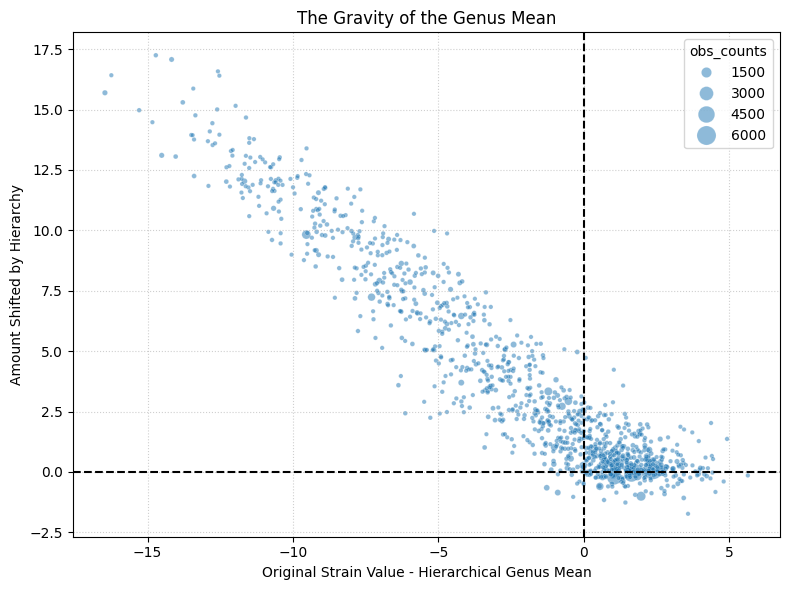

In [ ]:
# Extract the genus-level means from the hierarchical model
genus_list = list(hpmf_model_wESM_Hie.genus_dict.keys())
beta_genus_H = hpmf_model_wESM_Hie.idata.posterior["beta_genus"].mean(dim=("chain", "draw")).values

# Create a dictionary and map it to our dataframe
genus_mean_dict = dict(zip(genus_list, beta_genus_H))
tmp_df['beta_genus_Hierarchy'] = tmp_df['genus'].map(genus_mean_dict)

# Calculate the distances
tmp_df['distance_to_genus'] = tmp_df['beta_strain_Original'] - tmp_df['beta_genus_Hierarchy']
tmp_df['hierarchical_shift'] = tmp_df['beta_strain_Hierarchy'] - tmp_df['beta_strain_Original']

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=tmp_df,
    x='distance_to_genus',
    y='hierarchical_shift',
    size='obs_counts',
    sizes=(10, 200),
    alpha=0.5,
    edgecolor='w'
)

# Add reference lines
plt.axhline(0, color='black', linestyle='--')
plt.axvline(0, color='black', linestyle='--')

plt.title("The Gravity of the Genus Mean")
plt.xlabel("Original Strain Value - Hierarchical Genus Mean")
plt.ylabel("Amount Shifted by Hierarchy")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

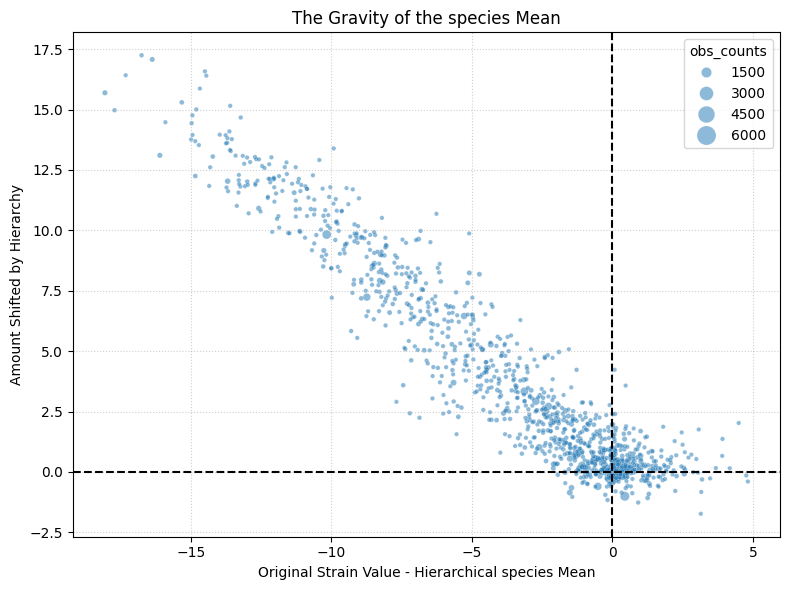

In [ ]:
# Extract the species-level means from the hierarchical model
species_list = list(hpmf_model_wESM_Hie.species_dict.keys())
beta_species_H = hpmf_model_wESM_Hie.idata.posterior["beta_species"].mean(dim=("chain", "draw")).values

# Create a dictionary and map it to our dataframe
species_mean_dict = dict(zip(species_list, beta_species_H))
tmp_df['beta_species_Hierarchy'] = tmp_df['species'].map(species_mean_dict)

# Calculate the distances
tmp_df['distance_to_species'] = tmp_df['beta_strain_Original'] - tmp_df['beta_species_Hierarchy']
tmp_df['hierarchical_shift'] = tmp_df['beta_strain_Hierarchy'] - tmp_df['beta_strain_Original']

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=tmp_df,
    x='distance_to_species',
    y='hierarchical_shift',
    size='obs_counts',
    sizes=(10, 200),
    alpha=0.5,
    edgecolor='w'
)

# Add reference lines
plt.axhline(0, color='black', linestyle='--')
plt.axvline(0, color='black', linestyle='--')

plt.title("The Gravity of the species Mean")
plt.xlabel("Original Strain Value - Hierarchical species Mean")
plt.ylabel("Amount Shifted by Hierarchy")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

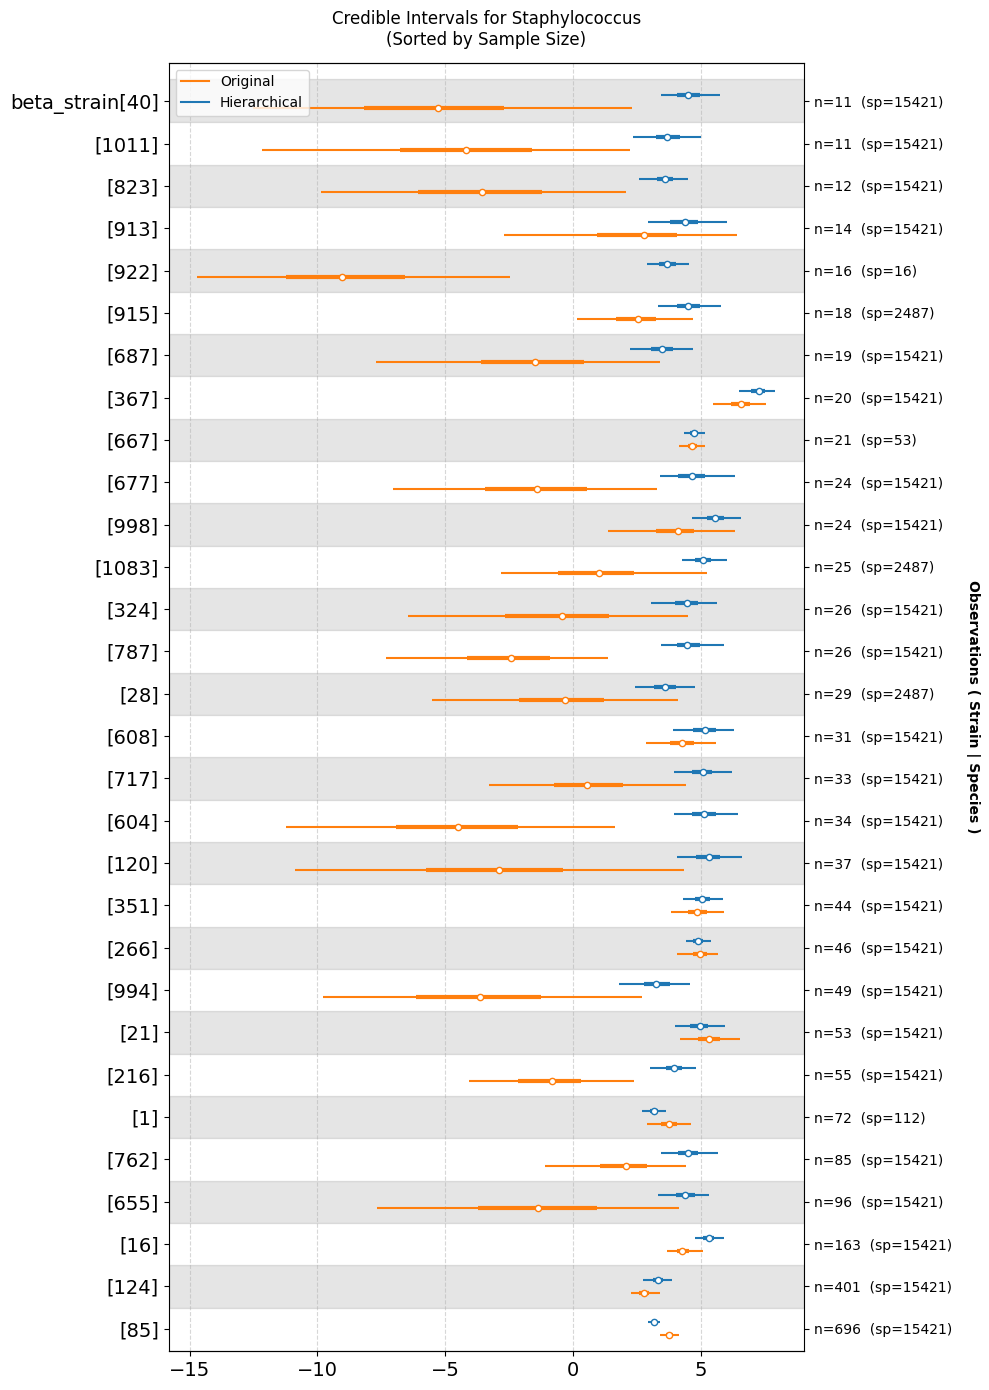

In [ ]:
# 1. Filter and Sort the DataFrame
target_genus = "Staphylococcus" # Change this to the genus you want to investigate
df_sub = tmp_df[tmp_df['genus'] == target_genus].copy()

# Sort by species_counts first, then strain obs_counts
# This groups related species together, ordered from rarest to most common
df_sub = df_sub.sort_values(by=['obs_counts', 'species_counts'], ascending=[True, True])
strains_in_genus = df_sub.index.tolist()

# If there are too many strains, the plot will be unreadable.
# We subsample to ~20, but keep them in the sorted order so the visual gradient remains.
if len(strains_in_genus) > 30:
    sampled_indices = sorted(np.random.choice(len(strains_in_genus), 30, replace=False))
    strains_in_genus = [strains_in_genus[i] for i in sampled_indices]

# 2. Draw the ArviZ Forest Plot
model_dict = {
    "Hierarchical": hpmf_model_wESM_Hie.idata,
    "Original": hpmf_model_wESM.idata
}

strain_ids = [hpmf_model_wESM.strain_dict[i] for i in strains_in_genus]
# ArviZ will respect the sorted order of the list we pass to coords
axes = az.plot_forest(
    list(model_dict.values()),
    model_names=list(model_dict.keys()),
    var_names=["beta_strain"],
    coords={"strain": strain_ids},
    combined=True,
    figsize=(10, len(strains_in_genus) * 0.4 + 2)
)

# 3. Hijack the plot to add the right-side metadata axis
ax = axes[0]
ax_right = ax.twinx() # Creates a second Y-axis that shares the same X-axis

# Lock the limits and ticks to perfectly match the left side
ax_right.set_ylim(ax.get_ylim())
ax_right.set_yticks(ax.get_yticks())

# Generate the custom count labels by reading ArviZ's left-side labels
count_labels = []
gen = (s for s in strains_in_genus)
for strain in strains_in_genus[::-1]:
    n_obs = int(tmp_df.loc[strain, 'obs_counts'])
    n_sp = int(tmp_df.loc[strain, 'species_counts'])

    # Format the right-hand text
    count_labels.append(f"n={n_obs}  (sp={n_sp})")


# Apply the text to the right axis and style it
ax_right.set_yticklabels(count_labels)
ax_right.set_ylabel("Observations ( Strain | Species )", rotation=270, labelpad=20, fontweight='bold')

# Final Formatting
ax.set_title(f"Credible Intervals for {target_genus}\n(Sorted by Sample Size)", pad=15)
ax.grid(True, axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

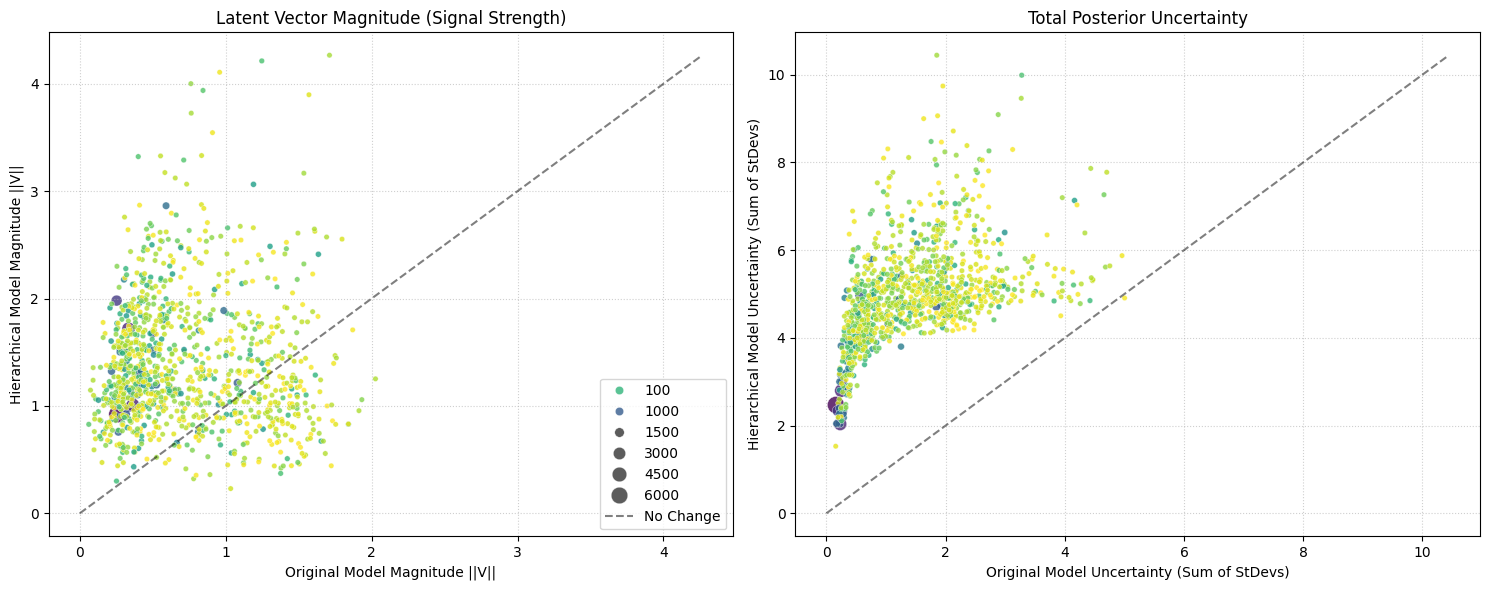

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

# 1. Extract Posterior Means and Standard Deviations
# Shape: (n_strains, latent_factors)
V_mean_Orig = hpmf_model_wESM.idata.posterior["V_strains"].mean(dim=("chain", "draw")).values
V_mean_Hie = hpmf_model_wESM_Hie.idata.posterior["V_strains"].mean(dim=("chain", "draw")).values

V_std_Orig = hpmf_model_wESM.idata.posterior["V_strains"].std(dim=("chain", "draw")).values
V_std_Hie = hpmf_model_wESM_Hie.idata.posterior["V_strains"].std(dim=("chain", "draw")).values

# 2. Calculate Rotation-Invariant Metrics
# Magnitude: Distance from the origin (0,0,...) in the latent space
tmp_df['V_mag_Original'] = np.linalg.norm(V_mean_Orig, axis=1)
tmp_df['V_mag_Hierarchy'] = np.linalg.norm(V_mean_Hie, axis=1)

# Uncertainty: Sum of the standard deviations across all latent dimensions
tmp_df['V_unc_Original'] = V_std_Orig.sum(axis=1)
tmp_df['V_unc_Hierarchy'] = V_std_Hie.sum(axis=1)

# 3. Create the Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot A: Magnitude Shrinkage ---
sns.scatterplot(
    data=tmp_df,
    x='V_mag_Original',
    y='V_mag_Hierarchy',
    hue='obs_counts',
    size='obs_counts',
    sizes=(15, 150),
    hue_norm=LogNorm(),  # Log color scale for counts
    palette='viridis_r',
    alpha=0.8,
    edgecolor='w',
    ax=axes[0]
)

# Reference line y=x
max_mag = max(tmp_df['V_mag_Original'].max(), tmp_df['V_mag_Hierarchy'].max())
axes[0].plot([0, max_mag], [0, max_mag], color='black', linestyle='--', alpha=0.5, label='No Change')

axes[0].set_title("Latent Vector Magnitude (Signal Strength)")
axes[0].set_xlabel("Original Model Magnitude ||V||")
axes[0].set_ylabel("Hierarchical Model Magnitude ||V||")
axes[0].legend()


# --- Plot B: Uncertainty Shrinkage ---
sns.scatterplot(
    data=tmp_df,
    x='V_unc_Original',
    y='V_unc_Hierarchy',
    hue='obs_counts',
    size='obs_counts',
    sizes=(15, 150),
    hue_norm=LogNorm(),
    palette='viridis_r',
    alpha=0.8,
    edgecolor='w',
    ax=axes[1]
)

# Reference line y=x
max_unc = max(tmp_df['V_unc_Original'].max(), tmp_df['V_unc_Hierarchy'].max())
axes[1].plot([0, max_unc], [0, max_unc], color='black', linestyle='--', alpha=0.5, label='No Change')

axes[1].set_title("Total Posterior Uncertainty")
axes[1].set_xlabel("Original Model Uncertainty (Sum of StDevs)")
axes[1].set_ylabel("Hierarchical Model Uncertainty (Sum of StDevs)")

# Only keep one legend to avoid clutter
axes[1].get_legend().remove()

for ax in axes:
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# Check original vs hierarchical U magnitudes
U_Orig_mag = np.linalg.norm(hpmf_model_wESM.idata.posterior["U"].mean(dim=("chain", "draw")).values, axis=1).mean()
U_Hie_mag = np.linalg.norm(hpmf_model_wESM_Hie.idata.posterior["U"].mean(dim=("chain", "draw")).values, axis=1).mean()

print(f"Original U Mean Magnitude: {U_Orig_mag:.2f}")
print(f"Hierarchical U Mean Magnitude: {U_Hie_mag:.2f}")

Original U Mean Magnitude: 8.21
Hierarchical U Mean Magnitude: 0.74


In [ ]:
U_mean_Orig = hpmf_model_wESM.idata.posterior["U"].mean(dim=("chain", "draw")).values
U_mean_Hie = hpmf_model_wESM_Hie.idata.posterior["U"].mean(dim=("chain", "draw")).values

# Assuming you have U_mean and V_mean matrices for both models
interaction_Orig = np.dot(U_mean_Orig, V_mean_Orig.T)
interaction_Hie = np.dot(U_mean_Hie, V_mean_Hie.T)

print(f"Original Interaction StDev: {interaction_Orig.std():.3f}")
print(f"Hierarchical Interaction StDev: {interaction_Hie.std():.3f}")

Original Interaction StDev: 3.709
Hierarchical Interaction StDev: 0.588


In [ ]:
get_loo_comparisons({'Original': hpmf_model_wESM,
                    'Hierarchical': hpmf_model_wESM_Hie})

Output()

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1089: RuntimeWarning: overflow encountered in expm1
  x = np.expm1(-kappa * np.log1p(-probs)) / kappa
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.67 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Output()

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 139 is different from 1280)
Apply node that caused the error: Dot(Cast{float32}.0, ExpandDims{axis=1}.0)
Toposort index: 11
Inputs types: [TensorType(float32, shape=(None, None)), TensorType(float64, shape=(None, 1))]
Inputs shapes: [(12617, 1280), (139, 1)]
Inputs strides: [(4, 50468), (8, 8)]
Inputs values: ['not shown', 'not shown']
Outputs clients: [[Squeeze{axis=1}(Dot.0)]]

Backtrace when the node is created (use PyTensor flag traceback__limit=N to make it longer):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 2975, in run_cell
    result = self._run_cell(
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3030, in _run_cell
    return runner(coro)
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/async_helpers.py", line 78, in _pseudo_sync_runner
    coro.send(None)

# Standard Linear vs. PMF (could also add the non-Hybrid PMF but would require changing model)

In [ ]:
hpmf_model_ESMPC_standard = Hybrid_PMF(test_few_df.copy(), phys_chem_norm.copy(), esm_pca_input.copy(),
                                 taxonomy_species, dim=10,
                                 include_esm=True, horseshoe=False, hierarchical=False, anchor_pc=True)

hpmf_model_ESMPC_standard.draw_samples(draws=1000, tune=1000, nuts_sampler="numpyro", init="jitter+adapt_diag", n_init=50000, chains=1)  # init="jitter+adapt_diag", n_init=50000,


/usr/local/lib/python3.12/dist-packages/pytensor/tensor/blas.py:1727: FutureWarning: batched_dot is deprecated. Use `dot` in conjunction with `tensor.vectorize` or `graph.replace.vectorize_graph`
  warnings.warn(
sample: 100%|██████████| 2000/2000 [30:33<00:00,  1.09it/s, 1023 steps of size 5.05e-03. acc. prob=0.91]
/usr/local/lib/python3.12/dist-packages/jax/_src/interpreters/mlir.py:1334: UserWarning: Some donated buffers were not usable: float64[1,1000,2].
See an explanation at https://docs.jax.dev/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

In [ ]:
hpmf_model_ESMPC_linear = Hybrid_PMF(test_few_df.copy(), phys_chem_norm.copy(), esm_input.copy(),
                                     taxonomy_species, dim=10, include_esm=True, horseshoe=False, linreg=True)

hpmf_model_ESMPC_linear.draw_samples(draws=1000, tune=1000, init="jitter+adapt_diag", nuts_sampler="numpyro", n_init=50000, chains=1)

sample: 100%|██████████| 2000/2000 [08:34<00:00,  3.89it/s, 255 steps of size 1.47e-02. acc. prob=0.92]
/usr/local/lib/python3.12/dist-packages/jax/_src/interpreters/mlir.py:1334: UserWarning: Some donated buffers were not usable: float64[1,1000,2].
See an explanation at https://docs.jax.dev/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

In [ ]:
hpmf_model_ESMPC_linear.idata.to_netcdf(os.path.join(file_path, "saved_models", "hpmf_model_ESMPC_linear.5_16.test_few.nc"))
hpmf_model_ESMPC_standard.idata.to_netcdf(os.path.join(file_path, "saved_models", "hpmf_model_ESMPC_standard.5_16.test_few.nc"))

'/content/drive/MyDrive/Courses/STATS305c/saved_models/hpmf_model_ESMPC_standard.5_16.test_few.nc'

In [ ]:
idata = az.from_netcdf(os.path.join(file_path, "saved_models", "hpmf_model_ESMPC_linear.5_16.test_few.nc"))
hpmf_model_ESMPC_linear = Hybrid_PMF(test_few_df.copy(), phys_chem_norm.copy(), esm_input.copy(),
                                     taxonomy_species, dim=10, include_esm=True, horseshoe=False, linreg=True,
                                     sigma_obs_sigma=1, b_pc_sigma=1, b_esm_sigma=1, beta_strains_sigma=1,)
hpmf_model_ESMPC_linear.idata = idata

idata = az.from_netcdf(os.path.join(file_path, "saved_models", "hpmf_model_ESMPC_standard.5_16.test_few.nc"))
hpmf_model_ESMPC_standard = Hybrid_PMF(test_few_df.copy(), phys_chem_norm.copy(), esm_pca_input.copy(),
                                 taxonomy_species, dim=10,
                                 include_esm=True, horseshoe=False, hierarchical=False, anchor_pc=True,
                                        sigma_obs_sigma=1, b_pc_sigma=1, b_esm_sigma=1, beta_strains_sigma=1)
hpmf_model_ESMPC_standard.idata = idata

/usr/local/lib/python3.12/dist-packages/pytensor/tensor/blas.py:1727: FutureWarning: batched_dot is deprecated. Use `dot` in conjunction with `tensor.vectorize` or `graph.replace.vectorize_graph`
  warnings.warn(


Output()

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.67 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Output()

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.67 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.67 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimat

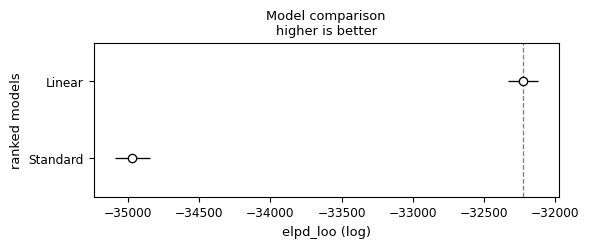

In [ ]:
std_linear_loos = get_loo_comparisons({'Standard': hpmf_model_ESMPC_standard,
                                     'Linear': hpmf_model_ESMPC_linear})

Look for failures (using loo_i?)

In [ ]:
# Should actually just add the loo_i for Standard and for Linear to the test_few_df
tmp_df = test_few_df.copy()
tmp_df['loo_i_standard'] = std_linear_loos['Standard'].loo_i.to_series().values
tmp_df['loo_i_linear'] = std_linear_loos['Linear'].loo_i.to_series().values
tmp_df = tmp_df.merge(taxonomy_species.drop_duplicates(), on='Target Species', how='left')
tmp_df = tmp_df.melt(
    id_vars=['strain', 'species', 'genus', 'mic_transformed','Peptide ID'],
    value_vars=['loo_i_standard', 'loo_i_linear'],
    var_name='model',
    value_name='loo_i')

<Axes: xlabel='species', ylabel='loo_i'>

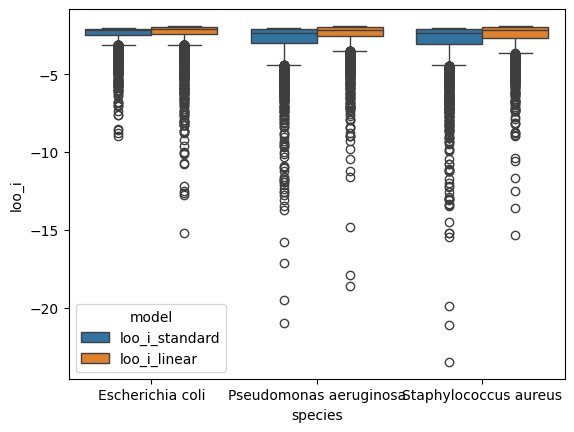

In [ ]:
sns.boxplot(tmp_df, x='species', y='loo_i', hue='model')

(<xarray.DataArray 'x' (chain: 1, draw: 1000)> Size: 8kB
 array([[-11.40282165, -11.12724527, -11.30066102, -12.2668855 ,
          -8.68316089, -12.26448084, -10.89570853, -11.97282751,
         -10.17411615,  -9.36093666,  -9.22142573, -10.91505421,
         -12.23322537, -10.56705838, -10.4762388 , -12.29547172,
         -12.21763878, -10.72003915, -12.05373326, -11.59770515,
         -12.26006091, -10.68832563,  -9.12612008, -10.96051815,
         -12.01152559, -10.89431232, -11.65821573, -11.58514359,
         -10.36881204, -11.67564136, -10.59089445, -10.27604022,
         -10.15120169, -10.96585595,  -9.82591436, -10.36200404,
         -11.74978869, -12.11280908, -12.9957007 , -10.36786695,
         -11.8064691 ,  -9.93050761, -11.68784016, -10.16836044,
         -10.40368655, -10.35077689,  -9.6323809 ,  -9.36258526,
         -10.82574513, -11.40459723, -10.43138829, -11.65382507,
          -9.77152762, -12.1029094 ,  -8.41556671, -12.81158428,
          -9.27637837, -11.445941

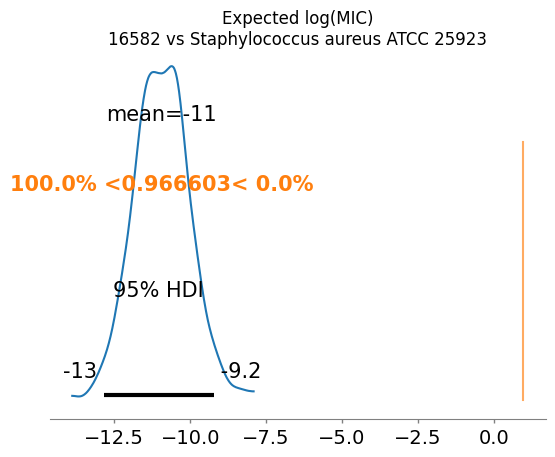

In [ ]:
arr = np.argpartition(tmp_df[tmp_df['model'] == 'loo_i_standard']['loo_i'], 20)[:20]
i = 0

hpmf_model_ESMPC_standard.plot_mic_posterior(tmp_df.iloc[arr[i]]['Peptide ID'],
                                             tmp_df.iloc[arr[i]]['strain'],
                                             true_mic=tmp_df.iloc[arr[i]]['mic_transformed'])

(<xarray.DataArray 'x' (chain: 1, draw: 1000)> Size: 8kB
 array([[2.77070104, 2.5484819 , 2.9840205 , 2.76865923, 2.98266424,
         3.20346084, 3.43774851, 3.01075815, 2.56683318, 3.11899823,
         2.79931866, 2.99541371, 2.56460233, 3.14279132, 2.71626785,
         2.86341266, 2.87970587, 2.99975742, 2.86784574, 3.11787406,
         2.71988105, 3.33796245, 2.74947708, 3.14449861, 3.0398598 ,
         2.78751192, 3.17594423, 3.15895334, 3.14620805, 3.22407044,
         2.8714044 , 3.0824868 , 3.22479059, 2.606975  , 2.86963413,
         3.02930867, 2.85912465, 3.12369313, 3.15531493, 3.24568456,
         2.91157669, 3.02264312, 3.04817948, 3.11482632, 3.46711236,
         2.91836713, 2.72274372, 2.71620173, 2.85834643, 2.70314031,
         2.93035577, 3.36317508, 2.72661043, 2.93487448, 3.16336123,
         2.99697316, 3.32285102, 3.13646779, 2.79539956, 3.3447626 ,
         2.77082976, 3.27050146, 3.32432049, 3.3108315 , 2.87619198,
         2.95294564, 3.20346798, 3.37625371, 3

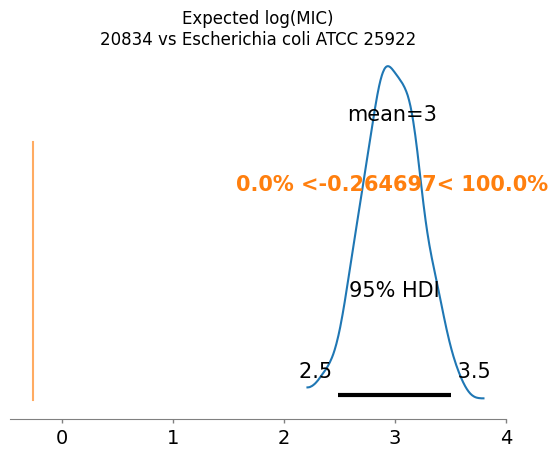

In [ ]:
# This is the best one, which is not very good!
# Is there a bug or mistake in how I am calling things? Indexing via iloc?
arr = [tmp_df[tmp_df['model'] == 'loo_i_standard']['loo_i'].idxmax()]
i = 0

hpmf_model_ESMPC_standard.plot_mic_posterior(tmp_df.iloc[arr[i]]['Peptide ID'],
                                             tmp_df.iloc[arr[i]]['strain'],
                                             true_mic=tmp_df.iloc[arr[i]]['mic_transformed'])

In [ ]:
hpmf_model_ESMPC_standard.strain_dict

{'Escherichia coli ATCC 25922': 0,
 'Pseudomonas aeruginosa ATCC 27853': 1,
 'Staphylococcus aureus ATCC 25923': 2}

# Investigate priors

In [ ]:
hpmf_model_wESM_og_priors = Hybrid_PMF(train_df.copy(), phys_chem_norm.copy(), esm_input.copy(),
                                taxonomy_species, dim=5, include_esm=True, horseshoe=False, hierarchical=False, anchor_pc=False,
                                       sigma_obs_sigma=1, b_pc_sigma=1, esm_sigma=1, beta_strains_sigma=1)

# hpmf_model_wESM_og_priors.draw_samples(draws=1000, tune=1000, nuts_sampler="numpyro", init="jitter+adapt_diag", n_init=50000, chains=1)  # init="jitter+adapt_diag", n_init=50000,
# hpmf_model_wESM_og_priors.idata.to_netcdf(os.path.join(file_path, "saved_models", "hpmf_model_wESM_og_priors.5_22.gt_10_species.nc"))

idata = az.from_netcdf(os.path.join(file_path, "saved_models", "hpmf_model_wESM_og_priors.5_22.gt_10_species.nc"))
hpmf_model_wESM_og_priors.idata = idata

/usr/local/lib/python3.12/dist-packages/pytensor/tensor/blas.py:1727: FutureWarning: batched_dot is deprecated. Use `dot` in conjunction with `tensor.vectorize` or `graph.replace.vectorize_graph`
  warnings.warn(


In [ ]:
hpmf_model_wESM = Hybrid_PMF(train_df.copy(), phys_chem_norm.copy(), esm_input.copy(),
                             taxonomy_species, dim=5, include_esm=True, horseshoe=False, hierarchical=False, anchor_pc=False)

# hpmf_model_wESM.draw_samples(draws=1000, tune=1000, nuts_sampler="numpyro", init="jitter+adapt_diag", n_init=50000, chains=1)  # init="jitter+adapt_diag", n_init=50000,
# hpmf_model_wESM.idata.to_netcdf(os.path.join(file_path, "saved_models", "hpmf_model_wESM.5_22.gt_10_species.nc"))

idata = az.from_netcdf(os.path.join(file_path, "saved_models", "hpmf_model_wESM.5_16.gt_10_species.nc"))
hpmf_model_wESM.idata = idata

/usr/local/lib/python3.12/dist-packages/pytensor/tensor/blas.py:1727: FutureWarning: batched_dot is deprecated. Use `dot` in conjunction with `tensor.vectorize` or `graph.replace.vectorize_graph`
  warnings.warn(


In [ ]:
with hpmf_model_wESM.model:
    # This samples from the priors and simulates the 'MIC_obs' node
    prior_idata = pm.sample_prior_predictive(samples=1000, random_seed=42)
with hpmf_model_wESM_og_priors.model:
    # This samples from the priors and simulates the 'MIC_obs' node
    prior_idata_og_priors = pm.sample_prior_predictive(samples=1000, random_seed=42)

idata = hpmf_model_wESM.idata
idata.extend(prior_idata)

idata = hpmf_model_wESM_og_priors.idata
idata.extend(prior_idata_og_priors)

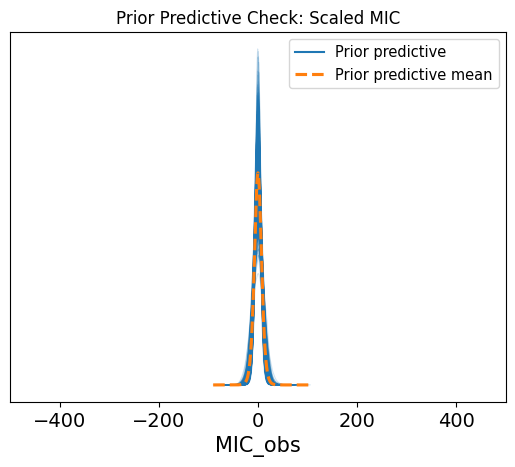

In [ ]:
# 2. Plot Prior Predictive vs. Actual Data
# This plots the KDE of your actual scaled MICs against the simulated ones
az.plot_ppc(prior_idata, group="prior", data_pairs={"MIC_obs": "MIC_obs"})
plt.title("Prior Predictive Check: Scaled MIC")
plt.xlim(-500, 500)
plt.show()

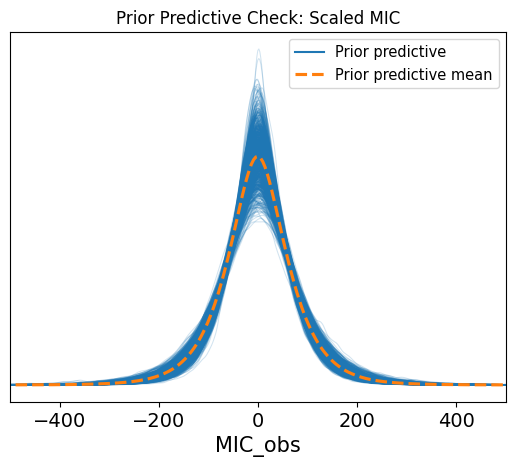

In [ ]:
az.plot_ppc(prior_idata_og_priors, group="prior", data_pairs={"MIC_obs": "MIC_obs"})
plt.title("Prior Predictive Check: Scaled MIC")
plt.xlim(-500, 500)
plt.show()

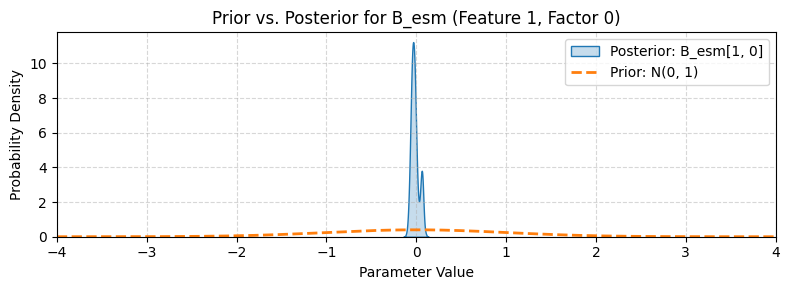

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm

# 1. Extract and flatten the posterior draws for this specific weight
posterior_draws = hpmf_model_wESM.idata.posterior.B_esm.isel(esm=1, latent_factor=0).values.flatten()

plt.figure(figsize=(8, 3))

# 2. Plot the Posterior (Blue, filled)
sns.kdeplot(posterior_draws, color="tab:blue", fill=True, label="Posterior: B_esm[1, 0]")

# 3. Plot the Prior N(0, 1) (Orange, dashed)
# Generate x values covering the relevant range (-4 to 4 covers 99.9% of N(0,1))
x_vals = np.linspace(-4, 4, 1000)
prior_pdf = norm.pdf(x_vals, loc=0, scale=1)
plt.plot(x_vals, prior_pdf, color="tab:orange", linestyle="--", linewidth=2, label="Prior: N(0, 1)")

# 4. Formatting
plt.title("Prior vs. Posterior for B_esm (Feature 1, Factor 0)")
plt.xlabel("Parameter Value")
plt.ylabel("Probability Density")

# Dynamically set x-limits just in case the posterior wanders,
# but guarantee it at least shows the full prior
plt.xlim(min(-4, posterior_draws.min()), max(4, posterior_draws.max()))

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

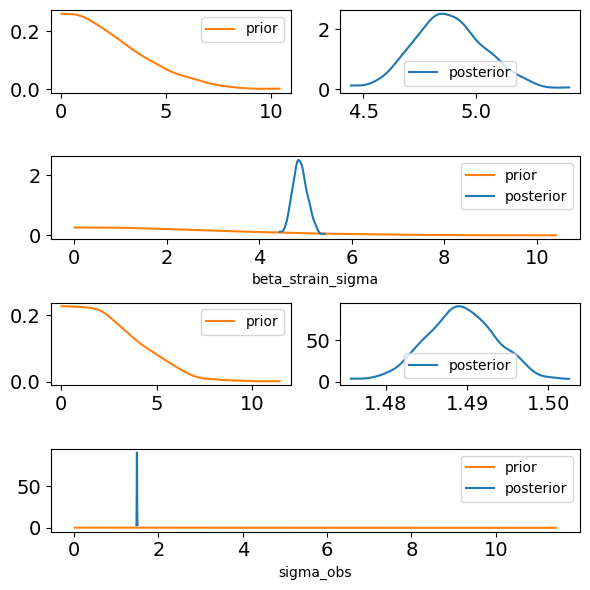

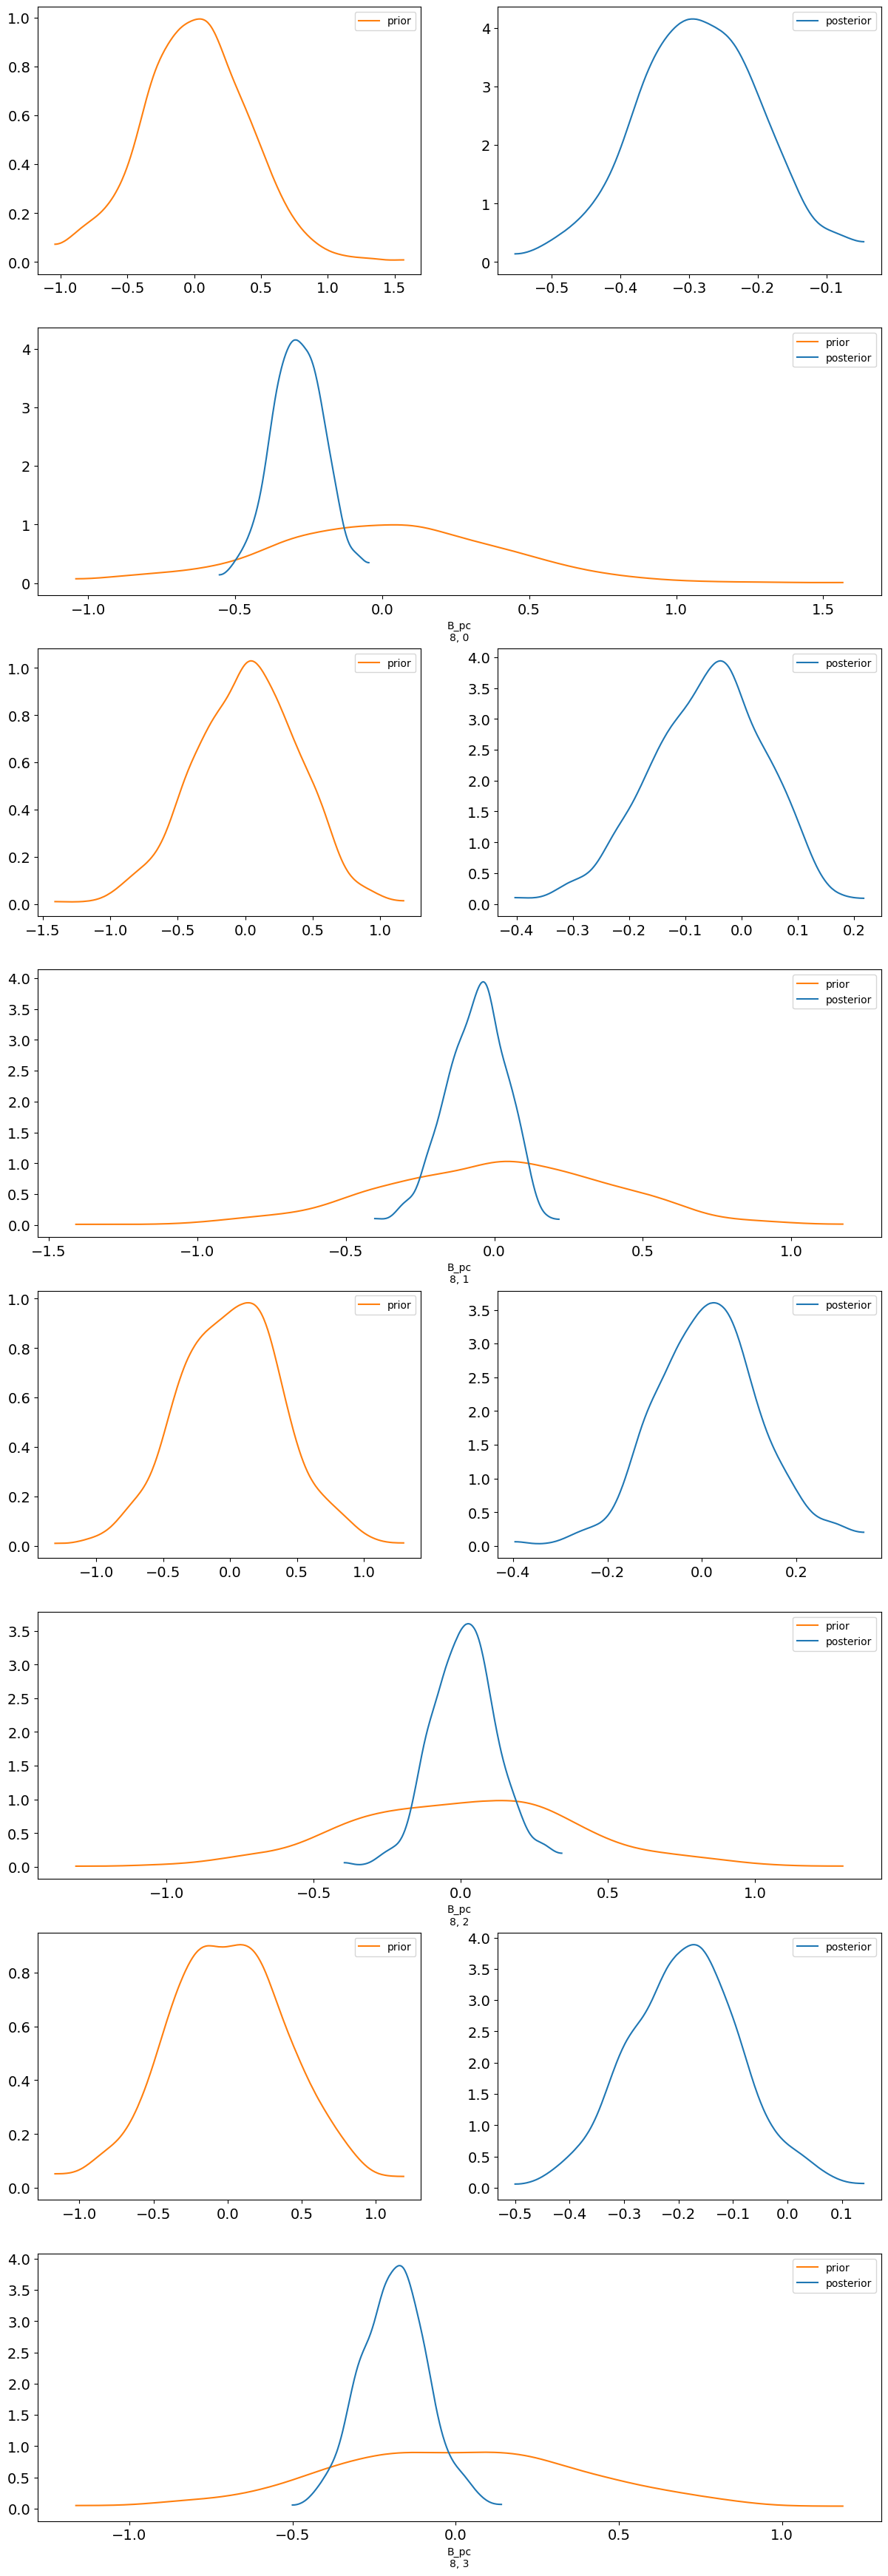

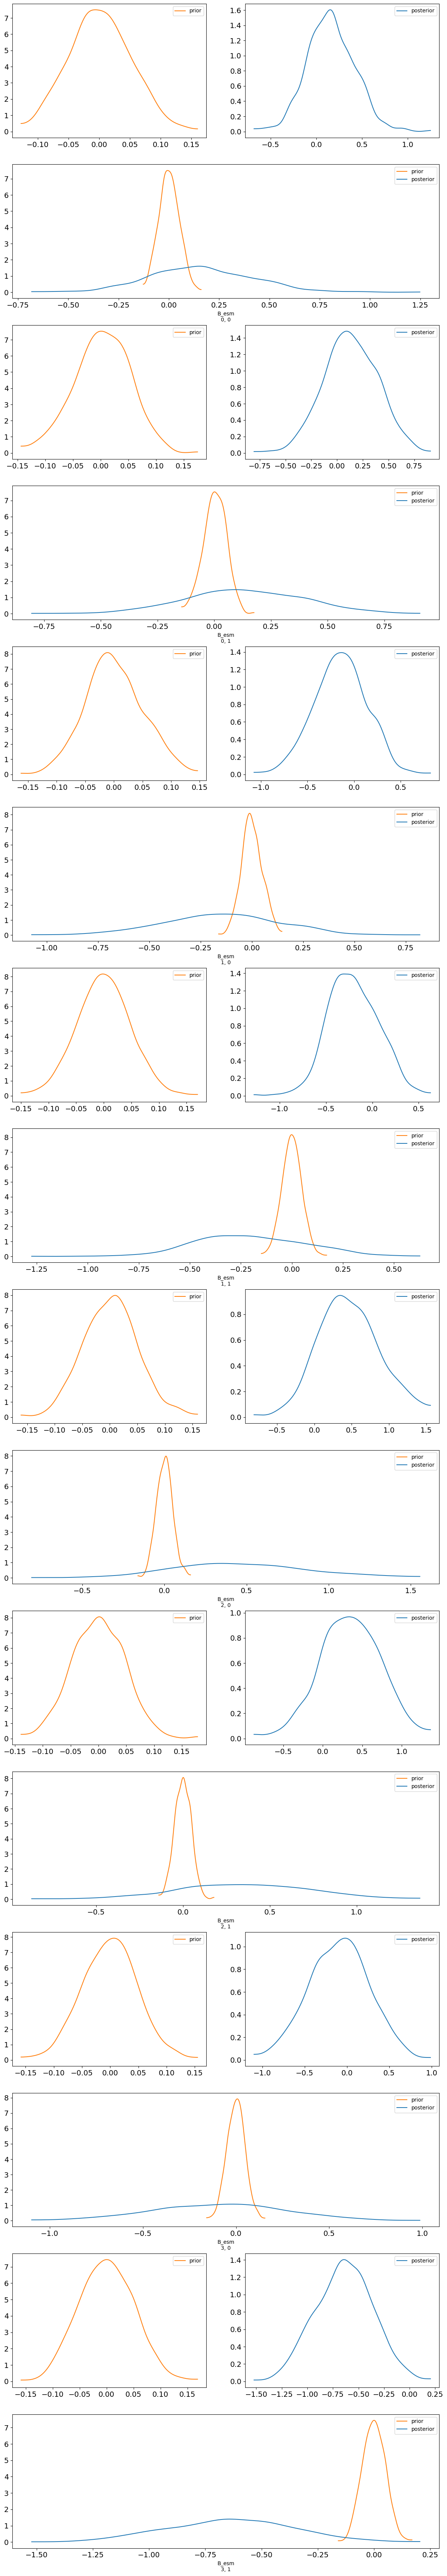

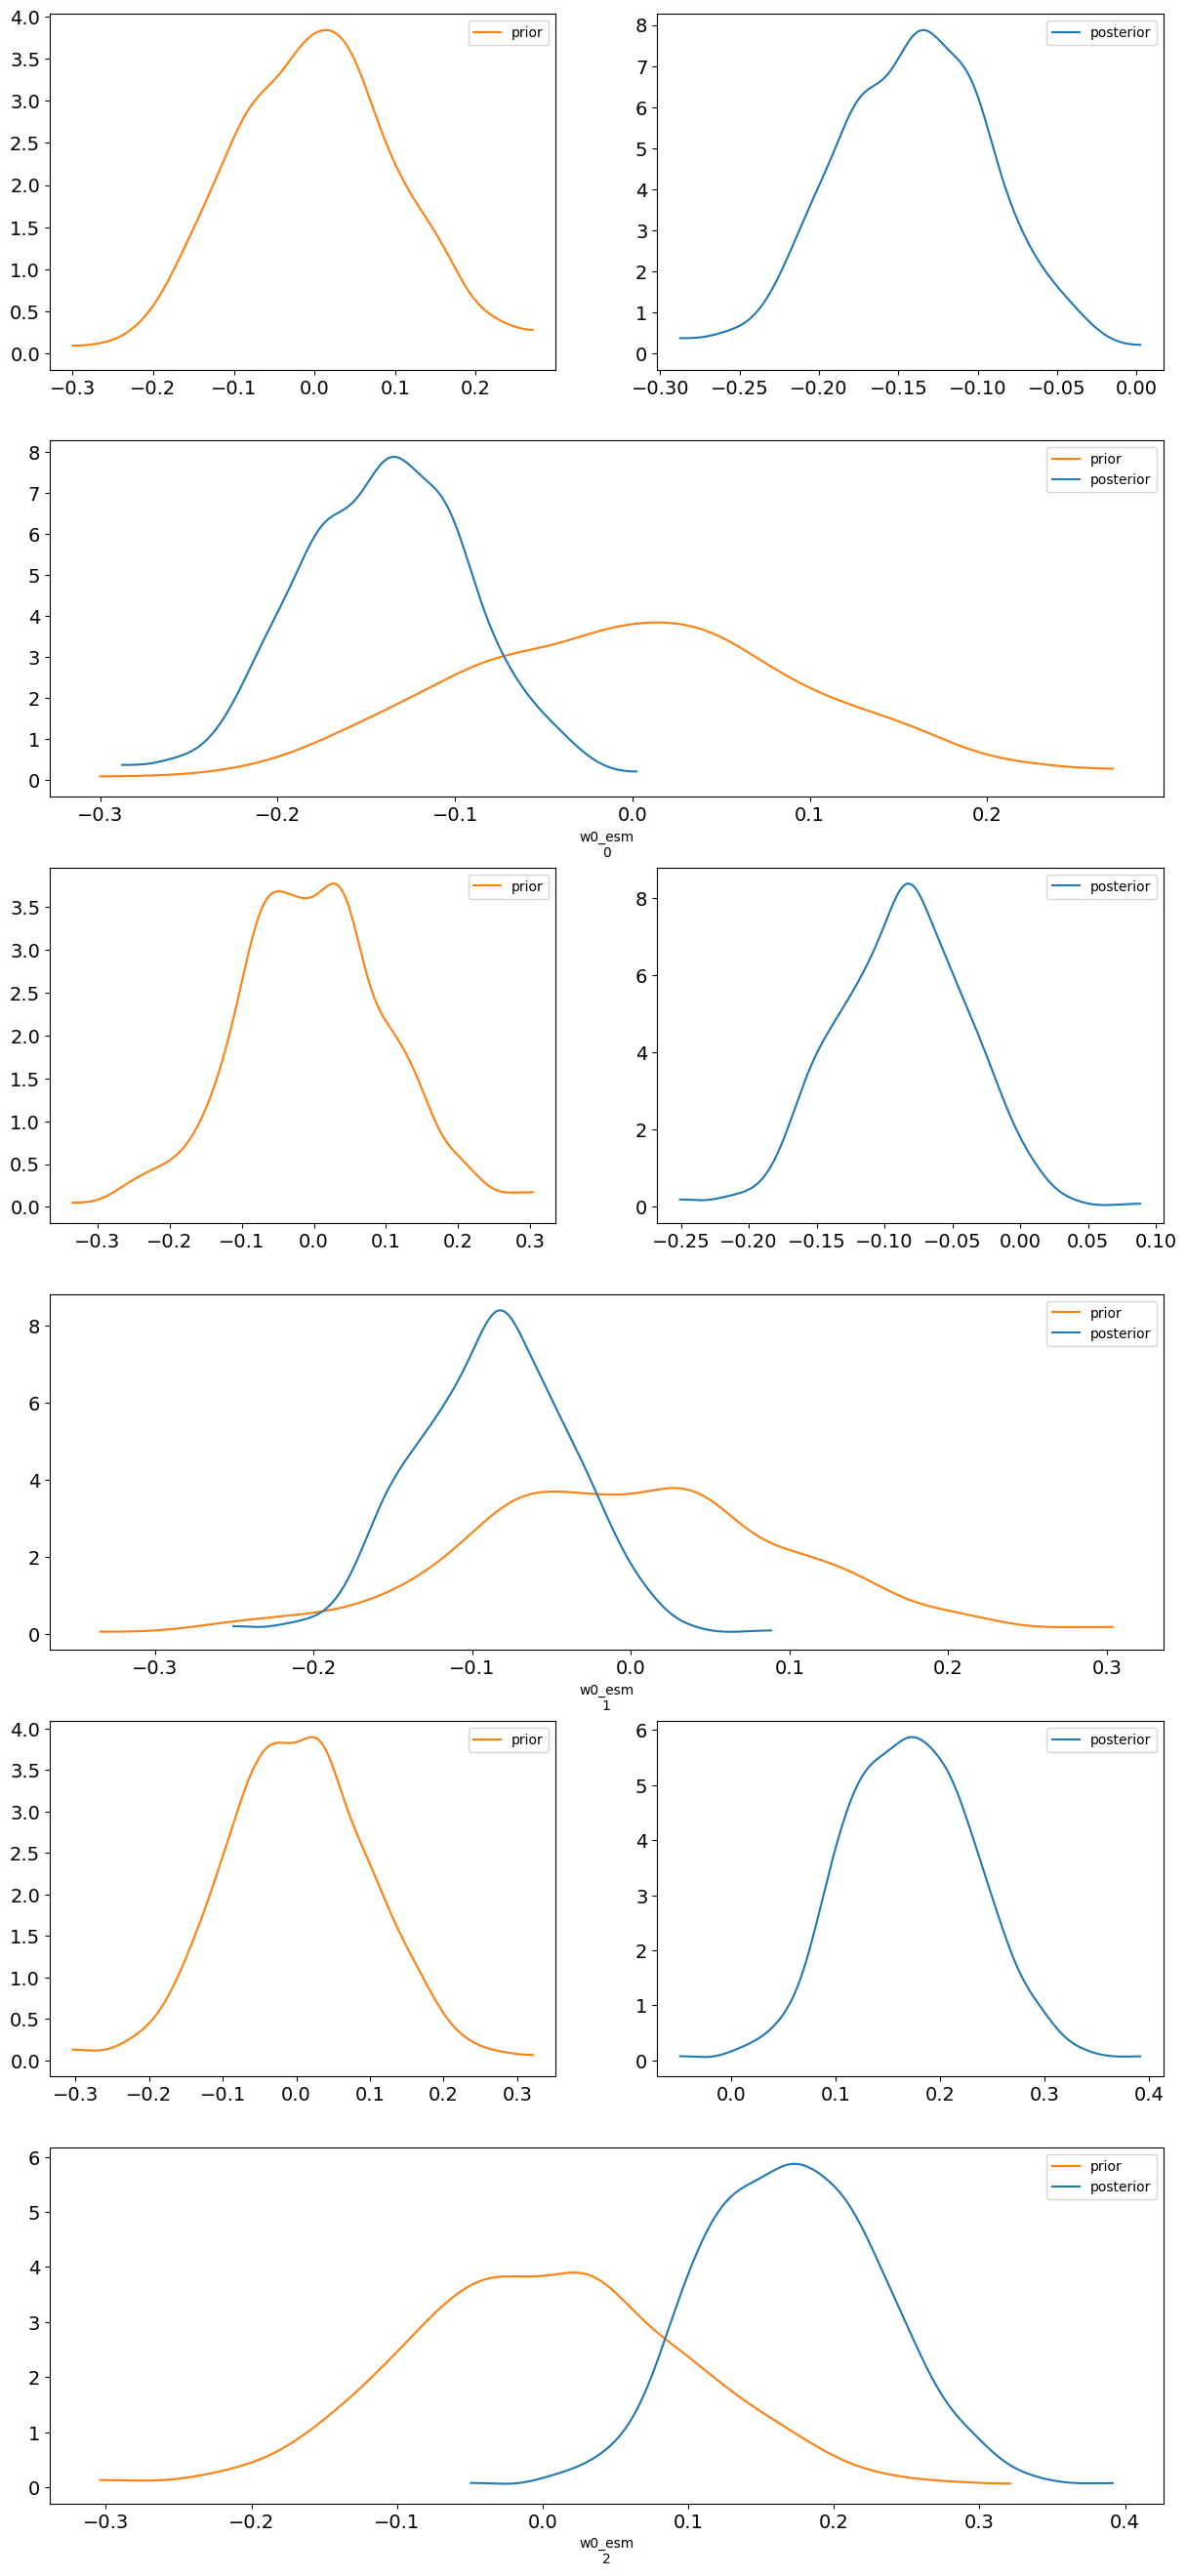

In [ ]:
# Assuming you already have your posterior `idata` from your MCMC run
# 1. Add the prior data into your existing idata object

# 2. Plot specific parameters (e.g., standard deviations and intercepts)
# var_names: put the parameters you are most suspicious of here
az.plot_dist_comparison(
    idata,
    var_names=["beta_strain_sigma", "sigma_obs"],
    kind="kde",
    figsize=(6,6)
)
plt.tight_layout()
plt.show()

# # You can also look at the latent weights (just picking the first few)
az.plot_dist_comparison(
    idata,
    var_names=["B_pc"],
    coords={"phys_chem": [8], "latent_factor": [0, 1, 2, 3]},
    kind="kde"
)
plt.show()

# # You can also look at the latent weights (just picking the first few) - Look at U values??
az.plot_dist_comparison(
    idata,
    var_names=["B_esm"],
    coords={"esm": [0,1,2,3], "latent_factor": [0, 1]},
    kind="kde"
)
plt.show()

# You can also look at the latent weights (just picking the first few)
# az.plot_dist_comparison(
#     idata,
#     var_names=["V_strains"],
#     coords={"strain": [0], "latent_factor": [0, 1, 2]},
#     kind="kde"
# )
# plt.show()

# # You can also look at the latent weights (just picking the first few)
# az.plot_dist_comparison(
#     idata,
#     var_names=["beta_strain"],
#     coords={"strain": [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]},
#     kind="kde"
# )
# plt.show()

# You can also look at the latent weights (just picking the first few)
# az.plot_dist_comparison(
#     idata,
#     var_names=["w0_pc"],
#     coords={"phys_chem": [0, 1,2],},
#     kind="kde"
# )
# plt.show()

# You can also look at the latent weights (just picking the first few)
az.plot_dist_comparison(
    idata,
    var_names=["w0_esm"],
    coords={"esm": [0,1,2]},
    kind="kde"
)
plt.show()

In [ ]:
# Check for largest mean B_pc or B_esm - should maybe tighten these priors??
# divide by sqrt(dim) ?

# And maybe a little wider obs prior? (can keep half-normal though?) -> 3
# Definitely wider on the beta_strains (many are at the edge, at 4) -> change to sigma 3 or 5? Or heavier tails?

# the w0s seem a little more informative than the U's

In [ ]:
B_pc_mean_xr = hpmf_model_wESM.idata.posterior['B_pc'].mean(dim=["chain", "draw"])
print(B_pc_mean_xr.values.min())
print(B_pc_mean_xr.values.max())

-1.042789963750133
0.9127137028066694


In [ ]:
B_pc_mean_xr = hpmf_model_wESM_og_priors.idata.posterior['B_pc'].mean(dim=["chain", "draw"])
print(B_pc_mean_xr.values.min())
print(B_pc_mean_xr.values.max())

-1.103232478502358
0.9315824649731003


In [ ]:
B_esm_mean_xr = hpmf_model_wESM.idata.posterior['B_esm'].mean(dim=["chain", "draw"])
print(B_esm_mean_xr.values.min())
print(B_esm_mean_xr.values.max())

-1.7696815182619896
2.1653772119549117


In [ ]:
B_esm_mean_xr = hpmf_model_wESM_og_priors.idata.posterior['B_esm'].mean(dim=["chain", "draw"])
print(B_esm_mean_xr.values.min())
print(B_esm_mean_xr.values.max())

-1.9584356720722134
2.233809507996133


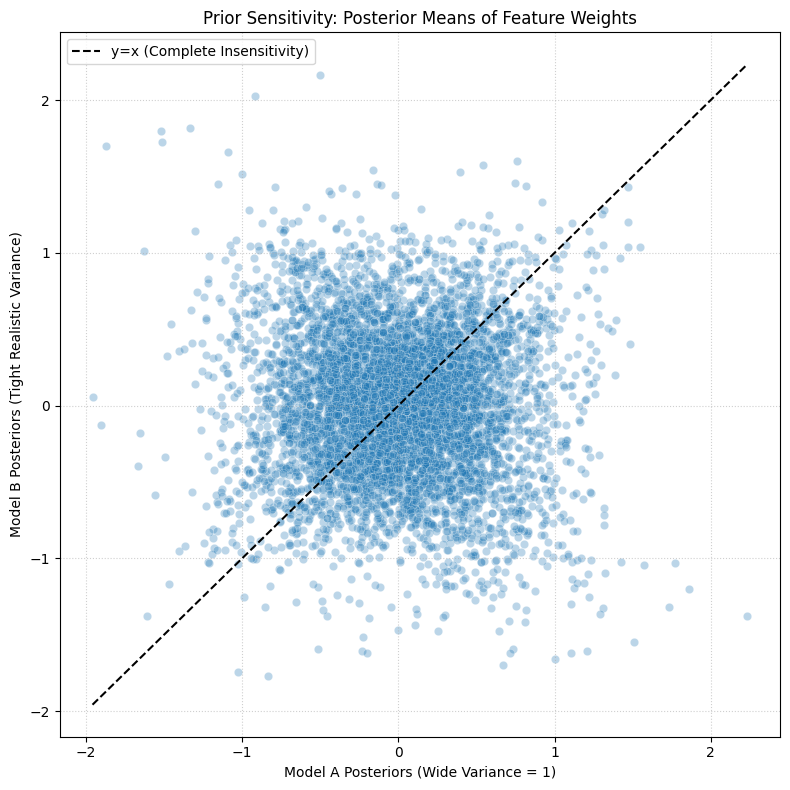

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Extract feature weights from both models (e.g., your ESM interaction weights)
# Model A: Wide/Unrealistic Priors, Model B: Tight/Realistic Priors
weights_wide = hpmf_model_wESM_og_priors.idata.posterior["B_esm"].mean(dim=("chain", "draw")).values.flatten()
weights_tight = hpmf_model_wESM.idata.posterior["B_esm"].mean(dim=("chain", "draw")).values.flatten()

plt.figure(figsize=(8, 8))
sns.scatterplot(x=weights_wide, y=weights_tight, alpha=0.3, edgecolor='w')

# Reference lines
limits = [
    min(weights_wide.min(), weights_tight.min()),
    max(weights_wide.max(), weights_tight.max())
]
plt.plot(limits, limits, color='black', linestyle='--', label='y=x (Complete Insensitivity)')

plt.title("Prior Sensitivity: Posterior Means of Feature Weights")
plt.xlabel("Model A Posteriors (Wide Variance = 1)")
plt.ylabel("Model B Posteriors (Tight Realistic Variance)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

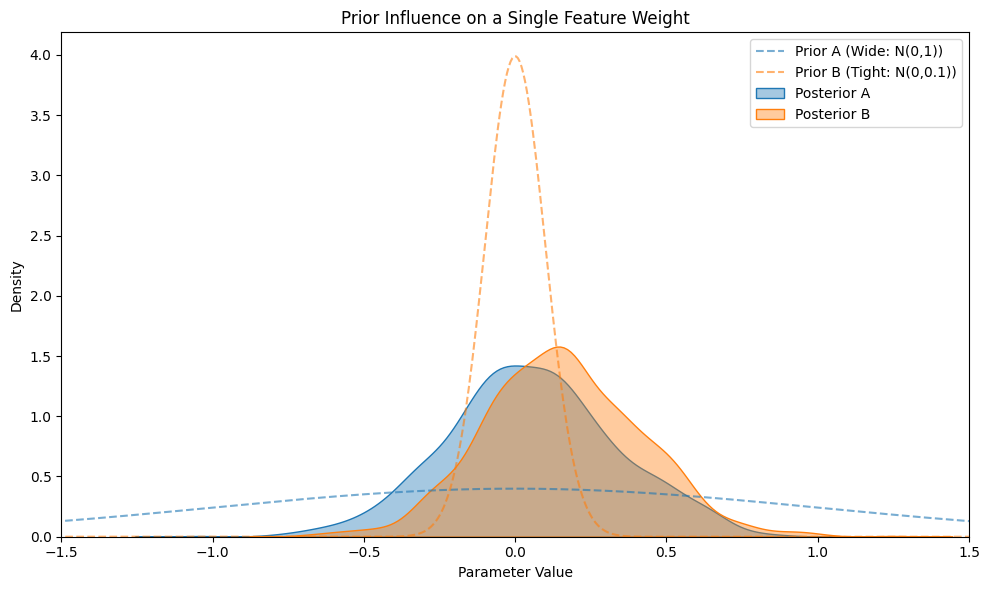

In [ ]:
from scipy.stats import norm

# Select a specific parameter to inspect (e.g., the first feature of latent factor 0)
post_wide = hpmf_model_wESM_og_priors.idata.posterior["B_esm"].isel(esm=0, latent_factor=0).values.flatten()
post_tight = hpmf_model_wESM.idata.posterior["B_esm"].isel(esm=0, latent_factor=0).values.flatten()

# Define the X-axis range based on the wide prior
x_vals = np.linspace(-3, 3, 1000)

plt.figure(figsize=(10, 6))

# 1. Plot the Priors (Dashed lines)
plt.plot(x_vals, norm.pdf(x_vals, 0, 1), color='tab:blue', linestyle='--', alpha=0.6, label='Prior A (Wide: N(0,1))')
# Assuming tight prior was N(0, 0.1) -- adjust scale to match your actual Model B prior!
plt.plot(x_vals, norm.pdf(x_vals, 0, 0.1), color='tab:orange', linestyle='--', alpha=0.6, label='Prior B (Tight: N(0,0.1))')

# 2. Plot the Posteriors (Solid filled KDEs)
sns.kdeplot(post_wide, color='tab:blue', fill=True, alpha=0.4, label='Posterior A')
sns.kdeplot(post_tight, color='tab:orange', fill=True, alpha=0.4, label='Posterior B')

plt.title("Prior Influence on a Single Feature Weight")
plt.xlabel("Parameter Value")
plt.ylabel("Density")
plt.legend()
plt.xlim(-1.5, 1.5) # Zoom in to see the posteriors clearly
plt.tight_layout()
plt.show()

TypeError: `data` argument must have the group "posterior_predictive" for ppcplot

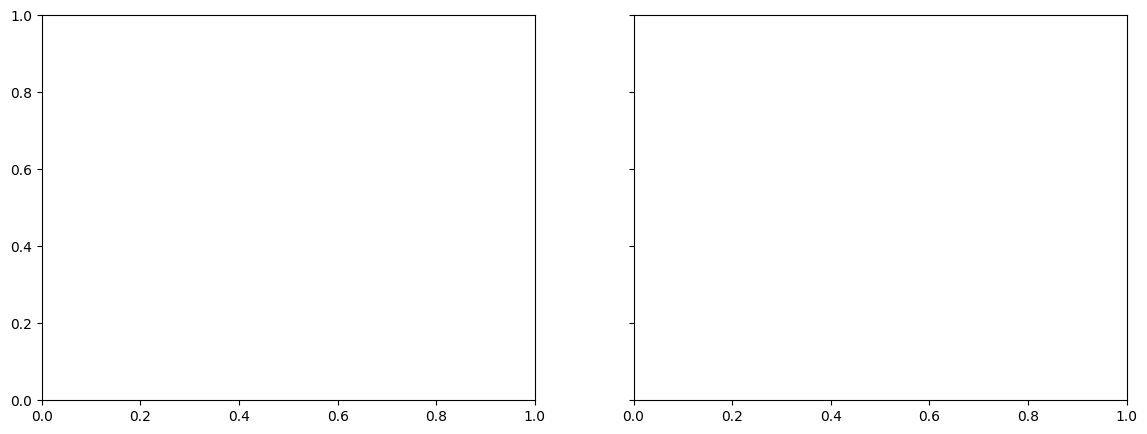

In [ ]:
import arviz as az

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

# Plot PPC for Model A (Wide Priors)
az.plot_ppc(hpmf_model_wESM_og_priors.idata, num_pp_samples=100, ax=axes[0], kind='kde')
axes[0].set_title("Model A (Wide Feature Priors)")
axes[0].set_xlim(hold_peptides_test["mic"].min() - 2, hold_peptides_test["mic"].max() + 2)

# Plot PPC for Model B (Tight Realistic Priors)
az.plot_ppc(hpmf_model_wESM.idata, num_pp_samples=100, ax=axes[1], kind='kde')
axes[1].set_title("Model B (Realistic Priors)")

plt.suptitle("Posterior Predictive Checks: True MIC vs Simulated MIC", y=1.05)
plt.tight_layout()
plt.show()

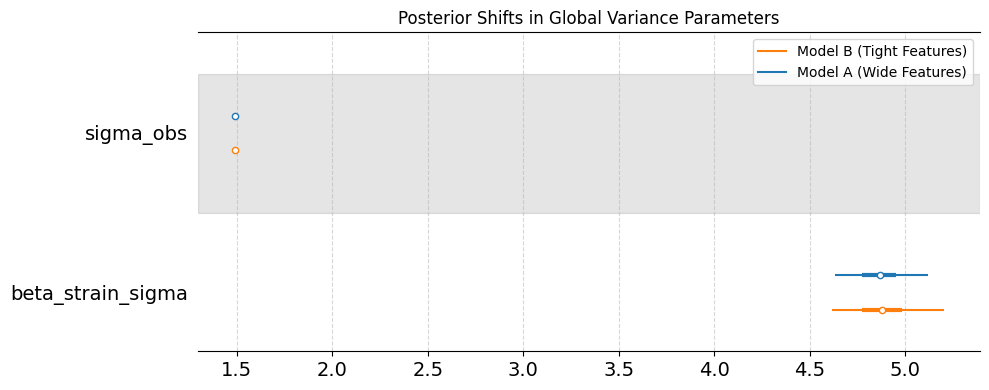

In [ ]:

# Group the InferenceData objects
# Replace with your actual model variables and names
models = {
    "Model A (Wide Features)": hpmf_model_wESM_og_priors.idata,
    "Model B (Tight Features)": hpmf_model_wESM.idata
}

# Plot the global error terms and hierarchical variances side-by-side
# Adjust var_names to match whatever you named your sigma parameters!
fig, ax = plt.subplots(figsize=(10, 4))
az.plot_forest(
    list(models.values()),
    model_names=list(models.keys()),
    var_names=["sigma_obs", "beta_strain_sigma"],
    combined=True,
    colors=["tab:blue", "tab:orange"],
    ax=ax
)

plt.title("Posterior Shifts in Global Variance Parameters")
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

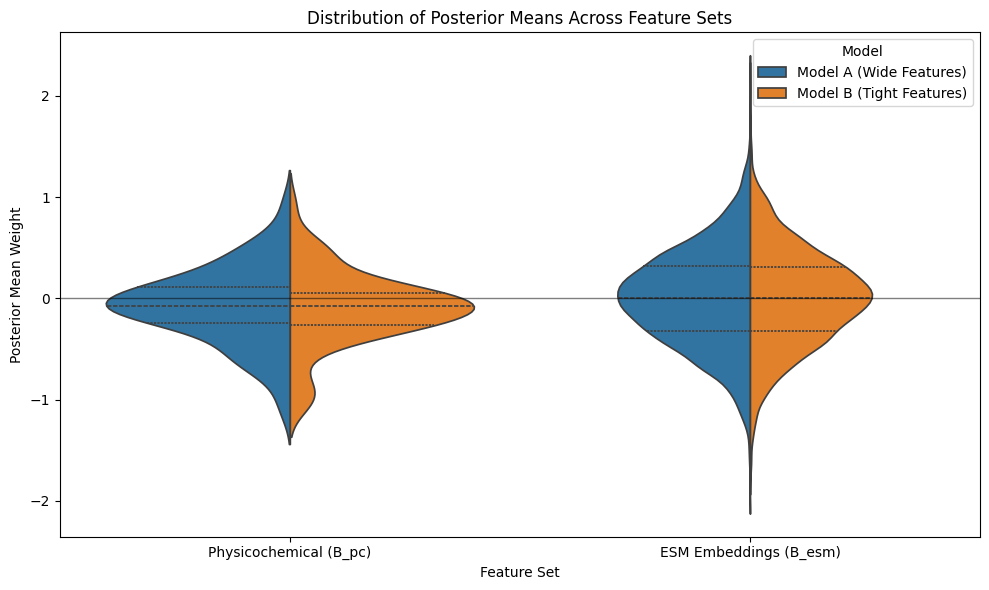

In [ ]:

def extract_flat_means(idata, var_name):
    """Flattens the posterior means of a matrix into a 1D array."""
    return idata.posterior[var_name].mean(dim=("chain", "draw")).values.flatten()

# 1. Build a combined DataFrame of all feature weights
data = []
for model_name, idata in models.items():
    # Extract PC features
    pc_weights = extract_flat_means(idata, "B_pc")
    data.extend([{"Model": model_name, "Feature Set": "Physicochemical (B_pc)", "Weight": w} for w in pc_weights])

    # Extract ESM features
    esm_weights = extract_flat_means(idata, "B_esm")
    data.extend([{"Model": model_name, "Feature Set": "ESM Embeddings (B_esm)", "Weight": w} for w in esm_weights])

df_weights = pd.DataFrame(data)

# 2. Plot the distributions
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df_weights,
    x="Feature Set",
    y="Weight",
    hue="Model",
    split=True,       # Combines the two models into halves of the same violin
    inner="quartile", # Shows the median and interquartile range inside
    palette=["tab:blue", "tab:orange"]
)

plt.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
plt.title("Distribution of Posterior Means Across Feature Sets")
plt.ylabel("Posterior Mean Weight")
plt.tight_layout()
plt.show()

## Worst MIC

In [ ]:

with hpmf_model_wESM_PC.model:
    pm.compute_log_likelihood(hpmf_model_wESM_PC.idata)

loo = az.loo(hpmf_model_wESM_PC.idata)


Output()

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.67 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [ ]:
hpmf_model_wESM_PC.idata.posterior#['mic']

<xarray.Dataset> Size: 635MB
Dimensions:            (chain: 1, draw: 1000, esm: 139, latent_factor: 5,
                        phys_chem: 12, peptide: 11987, strain: 1093)
Coordinates:
  * chain              (chain) int64 8B 0
  * draw               (draw) int64 8kB 0 1 2 3 4 5 ... 994 995 996 997 998 999
  * esm                (esm) int64 1kB 0 1 2 3 4 5 6 ... 133 134 135 136 137 138
  * latent_factor      (latent_factor) int64 40B 0 1 2 3 4
  * phys_chem          (phys_chem) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * peptide            (peptide) int64 96kB 0 1 2 3 ... 11983 11984 11985 11986
  * strain             (strain) int64 9kB 0 1 2 3 4 ... 1088 1089 1090 1091 1092
Data variables:
    B_esm              (chain, draw, esm, latent_factor) float64 6MB 0.1306 ....
    B_pc               (chain, draw, phys_chem, latent_factor) float64 480kB ...
    U                  (chain, draw, peptide, latent_factor) float64 479MB ...
    V_strains          (chain, draw, strain, latent_factor) float64 44MB ...
    alpha_peptide      (chain, draw, peptide) float64 96MB ...
    beta_strain        (chain, draw, strain) float64 9MB 4.294 2.253 ... -1.05
    beta_strain_sigma  (chain, draw) float64 8kB 5.627 5.478 ... 5.316 5.289
    sigma_obs          (chain, draw) float64 8kB 1.796 1.799 ... 1.789 1.792
    w0_esm             (chain, draw, esm) float64 1MB ...
    w0_pc              (chain, draw, phys_chem) float64 96kB ...
Attributes:
    created_at:                 2026-05-18T04:47:03.184827+00:00
    arviz_version:              0.22.0
    inference_library:          numpyro
    inference_library_version:  0.21.0
    sampling_time:              1108.477617
    tuning_steps:               1000

(<xarray.DataArray 'x' (chain: 1, draw: 1000)> Size: 8kB
 array([[-40.62310655, -36.81081265, -45.16620038, -31.5539879 ,
         -46.70512174, -54.0661675 , -50.90099932, -26.00708133,
         -23.38741248, -47.68021287, -34.01686855, -37.26452407,
         -44.2232589 , -22.48829301, -53.51788491, -39.16223718,
         -24.02150581, -60.92151713, -70.14790754, -26.31441904,
         -37.20216838, -30.33654636, -50.36043953, -63.35292819,
         -24.61003446, -44.2170879 , -32.48196978, -38.32743787,
         -65.35793192, -61.87643813, -28.5774256 , -25.33453497,
         -25.33685418, -49.92152984, -42.28120718, -49.81288644,
         -30.06133672, -45.70190585, -26.21282135, -38.15488272,
         -41.39062148, -42.33123632, -46.0671673 , -44.00213408,
         -43.05064863, -21.04744566, -52.19779925, -21.62674585,
         -52.38246917, -46.18108738, -43.45003109, -27.45174958,
         -43.61954239, -45.70900999, -26.88776648, -34.10067598,
         -46.97624942, -36.992558

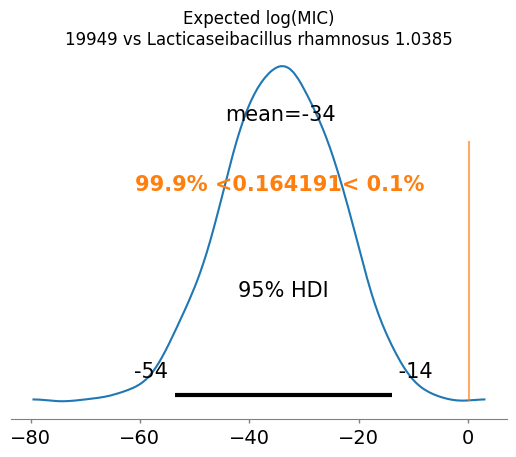

In [ ]:
tmp_df = most_species_df.copy()
tmp_df = tmp_df.merge(taxonomy_species.drop_duplicates(), on='Target Species', how='left')

# get worst
arr = np.argpartition(loo['loo_i'].to_series(), 20)[:20]
i = 0

hpmf_model_wESM_PC.plot_mic_posterior(tmp_df.iloc[arr[i]]['Peptide ID'],
                                             tmp_df.iloc[arr[i]]['strain'],
                                             true_mic=tmp_df.iloc[arr[i]]['mic_transformed'])

(<xarray.DataArray 'x' (chain: 1, draw: 1000)> Size: 8kB
 array([[-0.63984971, -0.43112785, -0.58116337, -0.65196294, -0.57008414,
         -0.96909471, -0.85135269, -0.77186385, -0.47935534, -0.85584315,
         -0.91097329, -0.77483793, -0.57443221, -0.67967339, -0.72359526,
         -0.9041444 , -0.90243983, -0.88231872, -0.71717711, -0.44931246,
         -1.04457478, -0.6199458 , -0.74933504, -0.80966336, -0.84401784,
         -0.57927177, -0.9157815 , -0.8573589 , -0.53211344, -0.66850865,
         -0.7676465 , -0.66643795, -0.66177818, -0.93885905, -1.08393369,
         -0.83856723, -0.79887907, -0.79019966, -0.68314928, -0.87583159,
         -0.76637749, -0.50840109, -0.69539174, -1.0125611 , -0.68345111,
         -1.05169386, -0.72607512, -0.81349902, -0.7787602 , -0.66315172,
         -0.6632713 , -0.94462223, -0.75319771, -0.54131966, -0.76216854,
         -0.85456571, -0.55863755, -0.6825568 , -0.98669226, -0.58765369,
         -0.72606337, -0.64971973, -0.66397595, -0.6072

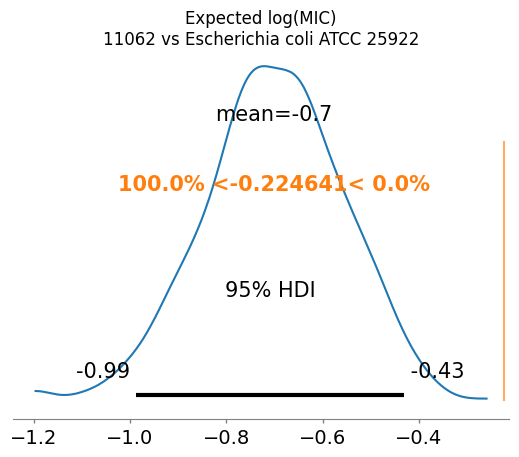

In [ ]:
# get best
arr = [loo['loo_i'].to_series().argmax()]
i = 0

hpmf_model_wESM_PC.plot_mic_posterior(tmp_df.iloc[arr[i]]['Peptide ID'],
                                             tmp_df.iloc[arr[i]]['strain'],
                                             true_mic=tmp_df.iloc[arr[i]]['mic_transformed'])

(<xarray.DataArray 'x' (chain: 1, draw: 1000)> Size: 8kB
 array([[6.21273908, 5.68647447, 6.17985538, 5.60237821, 5.22821911,
         6.12007243, 5.69362614, 5.43415299, 5.46458224, 5.97451897,
         5.60769258, 5.95608407, 5.36974205, 5.67144055, 5.26516883,
         5.80009831, 5.9365214 , 5.23728428, 5.95917812, 5.50698176,
         5.83101911, 5.54043574, 5.2395395 , 6.03262575, 5.52695604,
         5.94652869, 5.9659986 , 5.31377048, 5.53237346, 5.77417248,
         6.00576457, 5.43070323, 6.00891076, 4.3181612 , 6.81046754,
         5.03024865, 5.79121415, 4.22747362, 5.69452457, 6.28147255,
         5.72428956, 5.73813991, 6.78100199, 5.83239786, 6.71237614,
         5.65128832, 5.60103689, 5.11510134, 6.24591264, 5.36047483,
         5.89810525, 5.37553369, 5.1663505 , 4.77958838, 5.92106649,
         6.04820052, 5.37220888, 4.95117006, 6.13985761, 5.60369723,
         5.77985841, 5.54145464, 5.82895064, 5.18417317, 6.43952007,
         4.06003627, 5.42868005, 5.18271245, 5

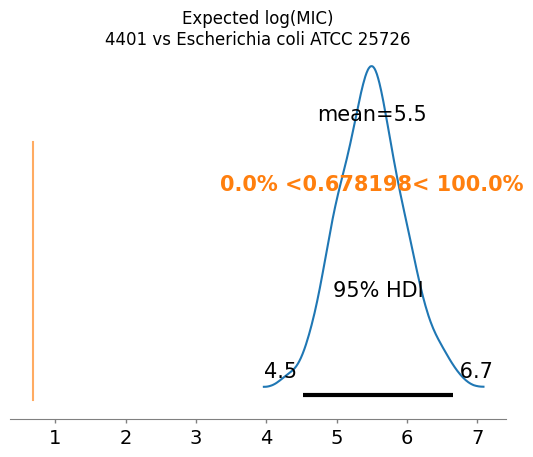

In [ ]:
i = 249

hpmf_model_wESM_PC.plot_mic_posterior(tmp_df.iloc[i]['Peptide ID'],
                                             tmp_df.iloc[i]['strain'],
                                             true_mic=tmp_df.iloc[i]['mic_transformed'])

## Strains

In [ ]:
strains

['Staphylococcus aureus',
 'Staphylococcus haemolyticus',
 'Staphylococcus saprophyticus',
 'Bacillus subtilis',
 'Escherichia coli K-12 D31',
 'Salmonella enterica',
 'Escherichia coli DH5alpha',
 'Morganella morganii',
 'Enterococcus faecium',
 'Candida albicans',
 'Saccharomyces cerevisiae',
 'Escherichia coli ATCC 25922',
 'Klebsiella pneumoniae KK3 9904',
 'Enterobacter cloacae HNTCC 53001',
 'Pseudomonas aeruginosa ATCC 27853',
 'Proteus mirabilis ATCC 25933',
 'Staphylococcus aureus NCTC 8325',
 'Staphylococcus epidermidis RP62A',
 'Enterococcus faecalis ATCC 29212',
 'Candida albicans ATCC 90028',
 'Enterobacter cloacae NHTCC 53001',
 'Staphylococcus aureus ATCC 700699',
 'Staphylococcus aureus ATCC 29213',
 'Batrachochytrium dendrobatidis',
 'Klebsiella pneumoniae ATCC 700603',
 'Staphylococcus aureus ATCC 33591',
 'Staphylococcus aureus ATCC 25923',
 'Candida albicans ATCC 18804',
 'Staphylococcus epidermidis RP62A/1',
 'Escherichia coli ATCC 25726',
 'Acinetobacter baumannii

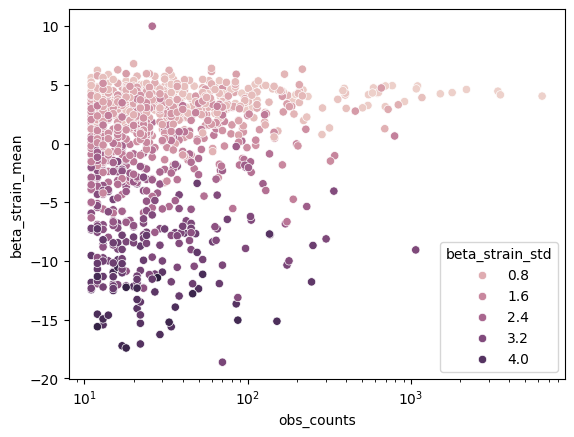

In [ ]:
strains = list(hpmf_model_wESM_PC.strain_dict.keys())
tmp_df = taxonomy_species.drop_duplicates().set_index('Target Species').loc[strains]
beta_strain_NoH = hpmf_model_wESM_PC.idata.posterior["beta_strain"].mean(dim=("chain","draw")).values
beta_strain_NoH_std = hpmf_model_wESM_PC.idata.posterior["beta_strain"].std(dim=("chain","draw")).values


counts = most_species_df['Target Species'].value_counts()
tmp_df['beta_strain_mean'] = beta_strain_NoH
tmp_df['beta_strain_std'] = beta_strain_NoH_std
tmp_df['obs_counts'] = counts.loc[strains]

sns.scatterplot(tmp_df, x='obs_counts', y='beta_strain_mean', hue='beta_strain_std')
plt.xscale('log')

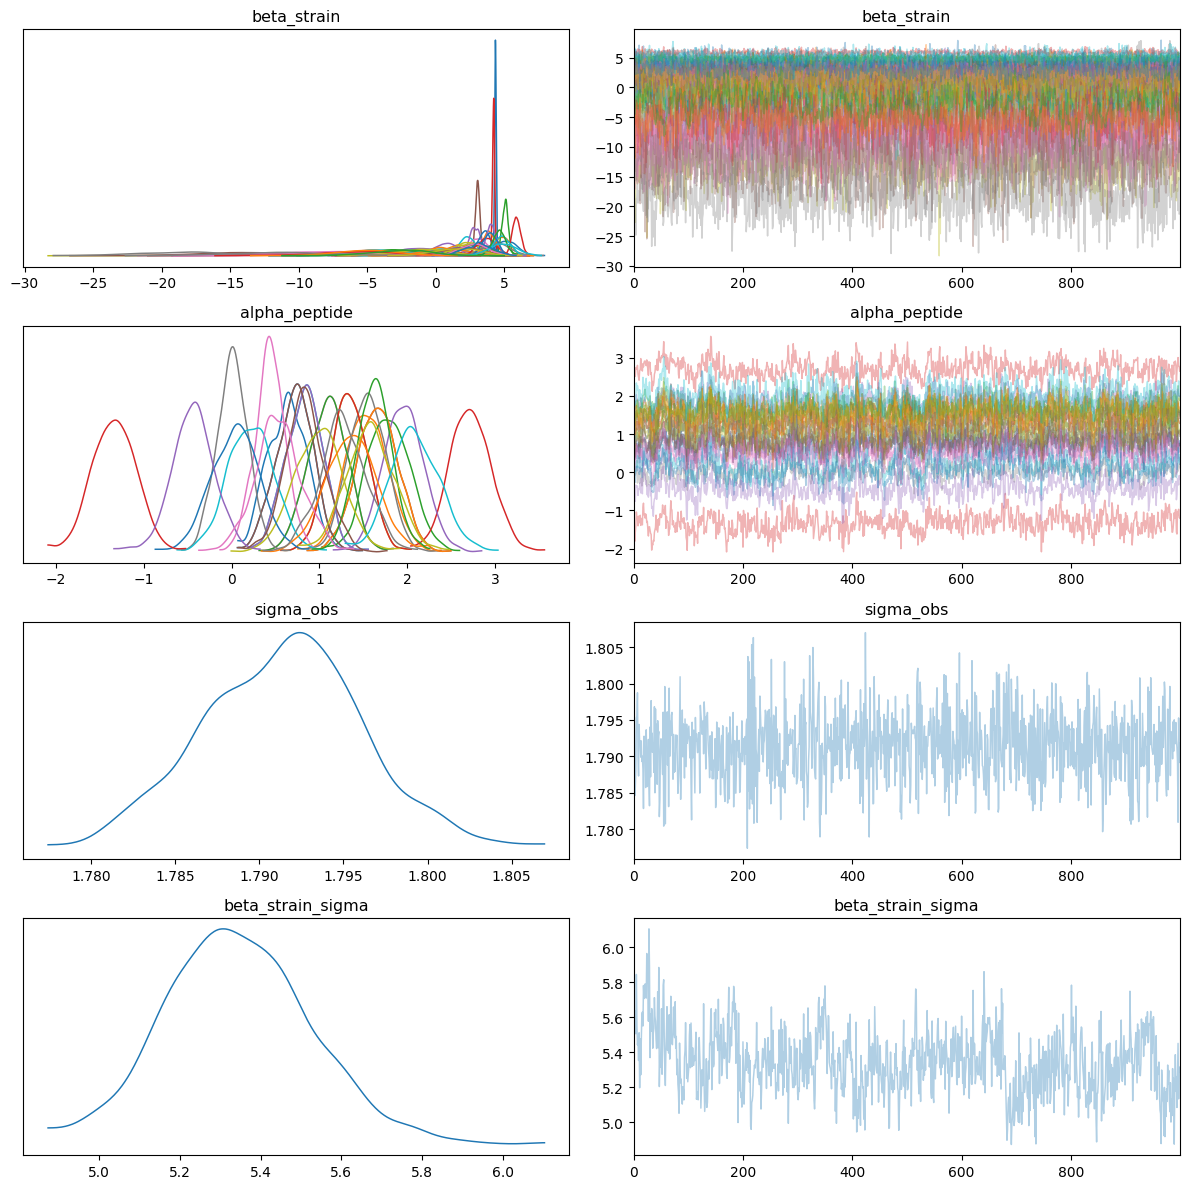

In [ ]:
hpmf_model_wESM_PC.plot_intercept_traces(
    species_list=most_species_df['Target Species'].unique()[::21],
    peptide_list=most_species_df['Peptide ID'].unique()[:30]
)

# Investigate Horseshoe

In [ ]:
# Horseshoe model
hpmf_model_wESM_HS = Hybrid_PMF(train_df.copy(), phys_chem_norm.copy(), esm_input.copy(),
                                taxonomy_species, dim=5, include_esm=True, horseshoe=True, hierarchical=False, anchor_pc=False, esm_active_num=15)

# hpmf_model_wESM_HS.draw_samples(draws=1000, tune=1000, nuts_sampler="numpyro", init="jitter+adapt_diag", n_init=50000, chains=1)
# hpmf_model_wESM_HS.idata.to_netcdf(os.path.join(file_path, "saved_models", "hpmf_model_wESM_HS.5_22.gt_10_species.nc"))

idata = az.from_netcdf(os.path.join(file_path, "saved_models", "hpmf_model_wESM_HS.5_22.gt_10_species.nc"))
hpmf_model_wESM_HS.idata = idata

/usr/local/lib/python3.12/dist-packages/pytensor/tensor/blas.py:1727: FutureWarning: batched_dot is deprecated. Use `dot` in conjunction with `tensor.vectorize` or `graph.replace.vectorize_graph`
  warnings.warn(


In [ ]:
hpmf_model_wESM = Hybrid_PMF(train_df.copy(), phys_chem_norm.copy(), esm_input.copy(),
                        taxonomy_species, dim=5, include_esm=True, horseshoe=False, hierarchical=False, anchor_pc=False)

# hpmf_model_wESM.draw_samples(draws=1000, tune=1000, nuts_sampler="numpyro", init="jitter+adapt_diag", n_init=50000, chains=1)  # init="jitter+adapt_diag", n_init=50000,
# hpmf_model_wESM.idata.to_netcdf(os.path.join(file_path, "saved_models", "hpmf_model_wESM.5_22.gt_10_species.nc"))

idata = az.from_netcdf(os.path.join(file_path, "saved_models", "hpmf_model_wESM.5_16.gt_10_species.nc"))
hpmf_model_wESM.idata = idata

/usr/local/lib/python3.12/dist-packages/pytensor/tensor/blas.py:1727: FutureWarning: batched_dot is deprecated. Use `dot` in conjunction with `tensor.vectorize` or `graph.replace.vectorize_graph`
  warnings.warn(


Output()

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.67 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Output()

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.67 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.67 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimat

{'No Horseshoe': Computed from 1000 posterior samples and 75904 observations log-likelihood matrix.
 
          Estimate       SE
 elpd_loo -145011.53   241.62
 p_loo    11410.09        -
 
 There has been a warning during the calculation. Please check the results.
 ------
 
 Pareto k diagnostic values:
                          Count   Pct.
 (-Inf, 0.67]   (good)     72159   95.1%
    (0.67, 1]   (bad)       3489    4.6%
    (1, Inf)   (very bad)   256    0.3%,
 'Horseshoe': Computed from 1000 posterior samples and 75904 observations log-likelihood matrix.
 
          Estimate       SE
 elpd_loo -145627.81   245.15
 p_loo     9221.83        -
 
 There has been a warning during the calculation. Please check the results.
 ------
 
 Pareto k diagnostic values:
                          Count   Pct.
 (-Inf, 0.67]   (good)     74395   98.0%
    (0.67, 1]   (bad)       1380    1.8%
    (1, Inf)   (very bad)   129    0.2%}

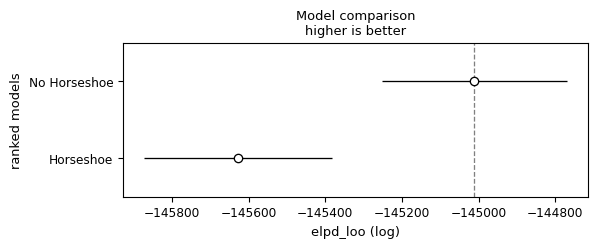

In [ ]:
get_loo_comparisons({'No Horseshoe': hpmf_model_wESM,
                    'Horseshoe': hpmf_model_wESM_HS})

This result makes sense. The horseshoe is adding regularization, so I would expect the performance to decrease slightly. But the hope would be it is more generalizable (less overfitting) and more interpretable.

In [ ]:
print('mean:', np.abs(hpmf_model_wESM.idata.posterior["B_esm"]).mean())
print('std:', hpmf_model_wESM.idata.posterior["B_esm"].std())
print('max:', hpmf_model_wESM.idata.posterior["B_esm"].max())


mean: <xarray.DataArray 'B_esm' ()> Size: 8B
array(0.48431412)
std: <xarray.DataArray 'B_esm' ()> Size: 8B
array(0.61473013)
max: <xarray.DataArray 'B_esm' ()> Size: 8B
array(4.22323335)


In [ ]:
print('mean:', np.abs(hpmf_model_wESM_HS.idata.posterior["B_esm"]).mean())
print('std:', hpmf_model_wESM_HS.idata.posterior["B_esm"].std())
print('max:', hpmf_model_wESM_HS.idata.posterior["B_esm"].max())

mean: <xarray.DataArray 'B_esm' ()> Size: 8B
array(0.06281359)
std: <xarray.DataArray 'B_esm' ()> Size: 8B
array(0.09586878)
max: <xarray.DataArray 'B_esm' ()> Size: 8B
array(1.01112998)


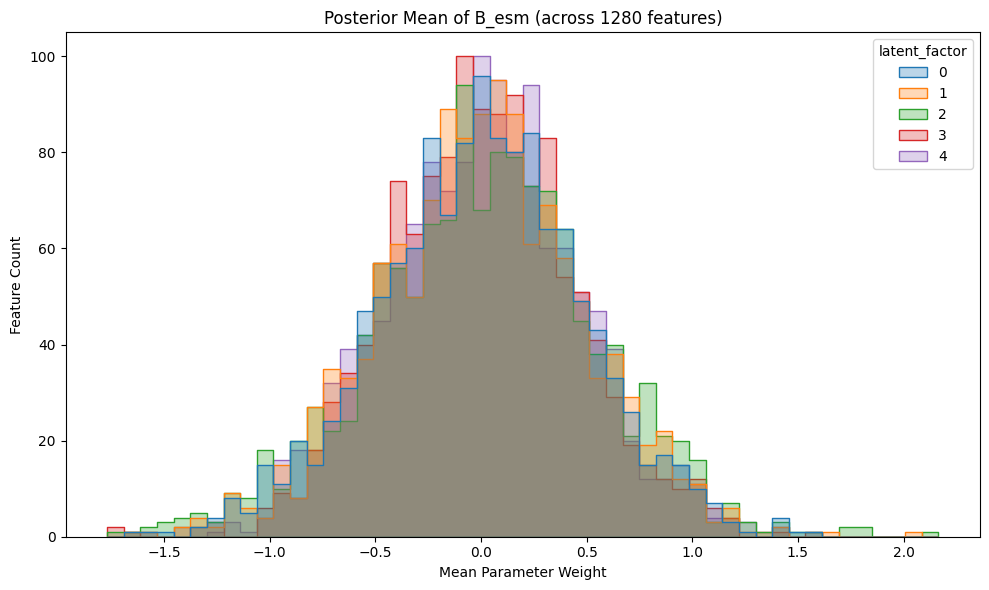

In [ ]:
# plot the mean of each chain across all 1280 features, with different color for each latent space

# 1. Take the mean across the MCMC sampling dimensions (chains and draws)
# This reduces the shape from (1, 1000, 1280, 5) down to (1280, 5)
b_esm_mean = hpmf_model_wESM.idata.posterior["B_esm"].mean(dim=["chain", "draw"])

# 2. Convert the xarray DataArray into a Pandas DataFrame
# This creates a 'long' format table with columns: ['esm', 'latent_factor', 'B_esm']
df_b_esm = b_esm_mean.to_dataframe().reset_index()

# 3. Treat latent_factor as a categorical variable so Seaborn uses distinct colors
df_b_esm["latent_factor"] = df_b_esm["latent_factor"].astype(str)

# 4. Plot the histogram
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_b_esm,
    x="B_esm",                 # The mean weight value
    hue="latent_factor",       # Color by latent space dimension
    element="step",            # 'step' draws overlapping outlines instead of solid blocks
    fill=True,
    alpha=0.3,                 # Make it transparent so overlapping distributions are visible
    bins=50
)

plt.title("Posterior Mean of B_esm (across 1280 features)")
plt.xlabel("Mean Parameter Weight")
plt.ylabel("Feature Count")
plt.tight_layout()
plt.show()

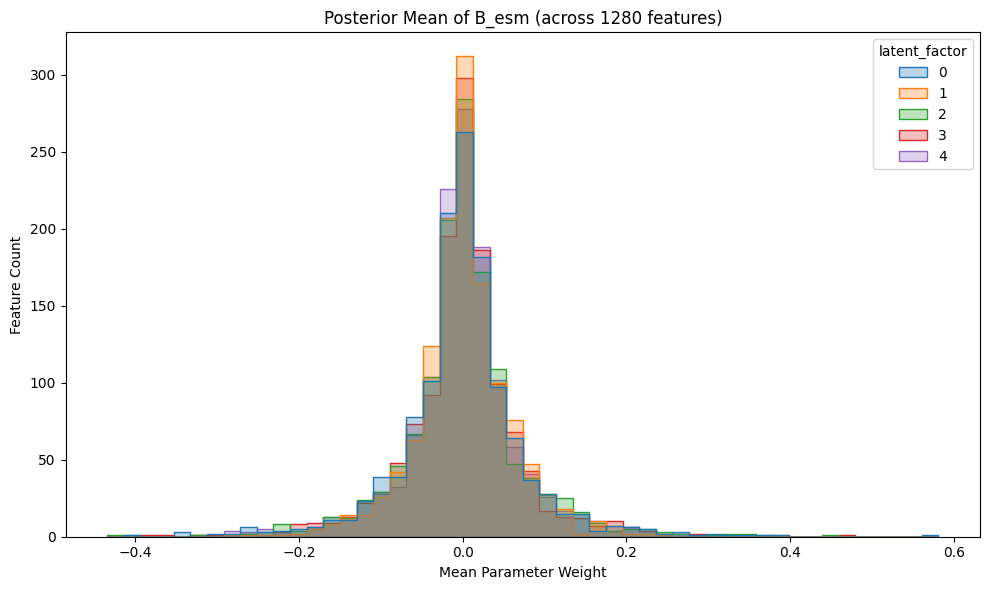

In [ ]:
# plot the mean of each chain across all 1280 features, with different color for each latent space

# 1. Take the mean across the MCMC sampling dimensions (chains and draws)
# This reduces the shape from (1, 1000, 1280, 5) down to (1280, 5)
b_esm_mean = hpmf_model_wESM_HS.idata.posterior["B_esm"].mean(dim=["chain", "draw"])

# 2. Convert the xarray DataArray into a Pandas DataFrame
# This creates a 'long' format table with columns: ['esm', 'latent_factor', 'B_esm']
df_b_esm = b_esm_mean.to_dataframe().reset_index()

# 3. Treat latent_factor as a categorical variable so Seaborn uses distinct colors
df_b_esm["latent_factor"] = df_b_esm["latent_factor"].astype(str)

# 4. Plot the histogram
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_b_esm,
    x="B_esm",                 # The mean weight value
    hue="latent_factor",       # Color by latent space dimension
    element="step",            # 'step' draws overlapping outlines instead of solid blocks
    fill=True,
    alpha=0.3,                 # Make it transparent so overlapping distributions are visible
    bins=50
)

plt.title("Posterior Mean of B_esm (across 1280 features)")
plt.xlabel("Mean Parameter Weight")
plt.ylabel("Feature Count")
plt.tight_layout()
plt.show()

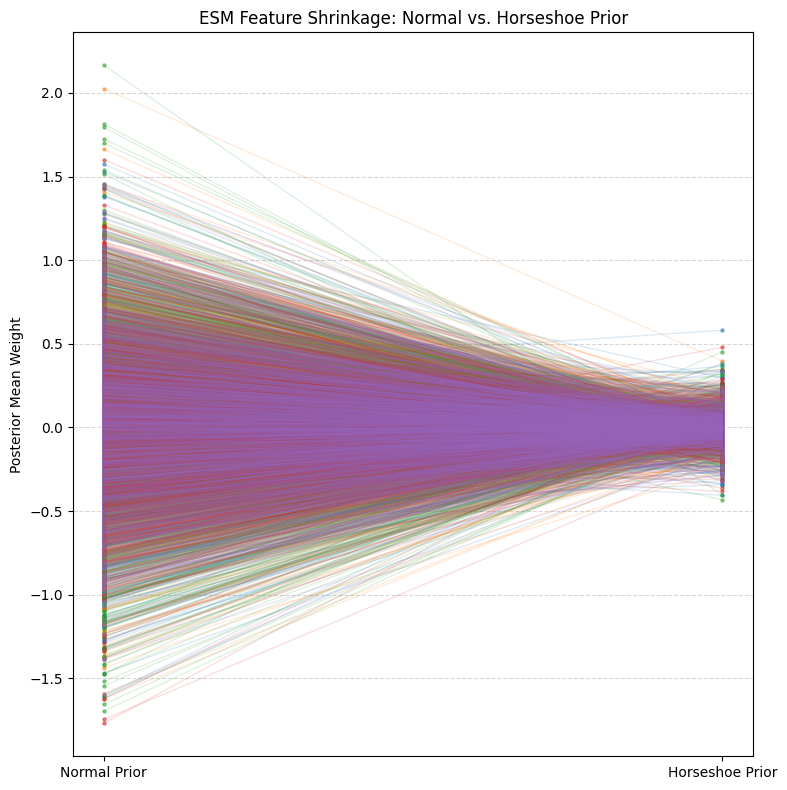

In [ ]:
plt.figure(figsize=(8, 8))
# 1. Extract means from the standard model
b_esm_norm = hpmf_model_wESM.idata.posterior["B_esm"].mean(dim=["chain", "draw"])
df_norm = b_esm_norm.to_dataframe(name="Normal").reset_index()

# 2. Extract means from the Horseshoe model
b_esm_hs = hpmf_model_wESM_HS.idata.posterior["B_esm"].mean(dim=["chain", "draw"])
df_hs = b_esm_hs.to_dataframe(name="Horseshoe").reset_index()

# 3. Merge them together on the feature and factor coordinates
df_compare = pd.merge(df_norm, df_hs, on=["esm", "latent_factor"])
df_compare["latent_factor"] = df_compare["latent_factor"].astype(str)

# Matplotlib trick: Passing a 2D array to plot draws all lines simultaneously and instantly
# We plot the X-axis as categorical ['Normal Prior', 'Horseshoe Prior']
x_labels = ['Normal Prior', 'Horseshoe Prior']

# We iterate through the 5 latent factors just to color-code them
colors = sns.color_palette("tab10", n_colors=df_compare["latent_factor"].nunique())

for idx, lf in enumerate(df_compare["latent_factor"].unique()):
    subset = df_compare[df_compare["latent_factor"] == lf]

    # Extract the paired values: shape becomes (2, N_features)
    y_vals = subset[['Normal', 'Horseshoe']].values.T

    # Draw the lines with low alpha so the dense areas don't become a solid block
    plt.plot(x_labels, y_vals, color=colors[idx], alpha=0.15, linewidth=1)

    # Overlay dots on the ends for visibility
    plt.scatter(np.zeros(len(subset)), subset['Normal'], color=colors[idx], s=5, alpha=0.5)
    plt.scatter(np.ones(len(subset)), subset['Horseshoe'], color=colors[idx], s=5, alpha=0.5)

plt.title("ESM Feature Shrinkage: Normal vs. Horseshoe Prior")
plt.ylabel("Posterior Mean Weight")
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

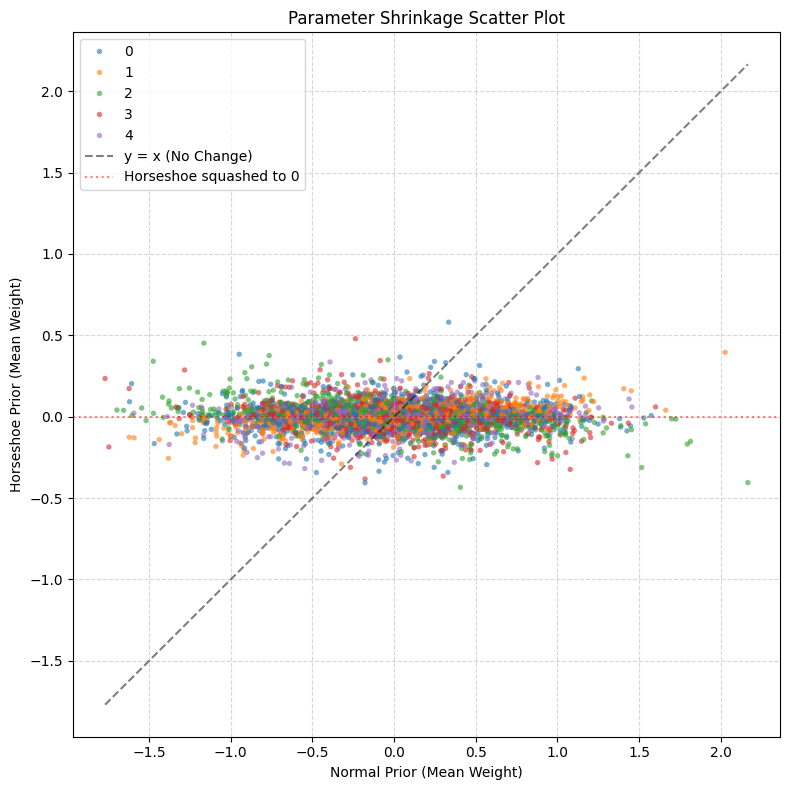

In [ ]:
plt.figure(figsize=(8, 8))

# Plot the weights against each other
sns.scatterplot(
    data=df_compare,
    x="Normal",
    y="Horseshoe",
    hue="latent_factor",
    alpha=0.6,
    s=15,
    edgecolor="none"
)

# Add a 45-degree reference line (x = y)
limits = [
    min(df_compare["Normal"].min(), df_compare["Horseshoe"].min()),
    max(df_compare["Normal"].max(), df_compare["Horseshoe"].max())
]
plt.plot(limits, limits, color='black', linestyle='--', alpha=0.5, label="y = x (No Change)")

# Add a horizontal line at 0 for the Horseshoe
plt.axhline(0, color='red', linestyle=':', alpha=0.5, label="Horseshoe squashed to 0")

plt.title("Parameter Shrinkage Scatter Plot")
plt.xlabel("Normal Prior (Mean Weight)")
plt.ylabel("Horseshoe Prior (Mean Weight)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()